<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW4_woodenML_base_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание 4 (base): древесные алгоритмы**

### **Постановка задачи:**

У вас есть данные о полетах, обладающие следущими характеристиками:
- Для **каждого** клиента известна краткая информация о самом человеке, о типе билета и о рейсе, а также оценки клиента различным аспектам полета.
- Для **некоторых** клиентов известна их удовлетворенность полетом (satisfied или neutral or dissatisfied).

По данным необходимо обучить модель, предсказывающую удовлетворенность клиентов полетом. Итоговые предсказания нужно сделать для клиентов, **для которых ответ неизвестен.**

### **Получение данных:**

Компания держит все данные в облаке Яндекса в Postgresql. Данные разбиты на смысловые таблицы. Чтобы получить данные, вам необходимо подключиться к базе данных и добыть оттуда данные.

### **Оценивание:**

- Как всегда оцениваются как код, так и ответы на вопросы. Если нет одного и/или другого, то часть баллов за соответствующее задание без колебаний снимается.
- Брать код из открытых источников позволительно. Следование культуре цитирования **обязательно.**

### **Баллы:**

Суммарно за задание можно получить 10 основных и 0.7 бонусных баллов.

Оценка за ДЗ = min{ваш балл, 10}

Мягкий дедлайн: 29 января 23:59

**Продуктивной и интересной вам работы!**

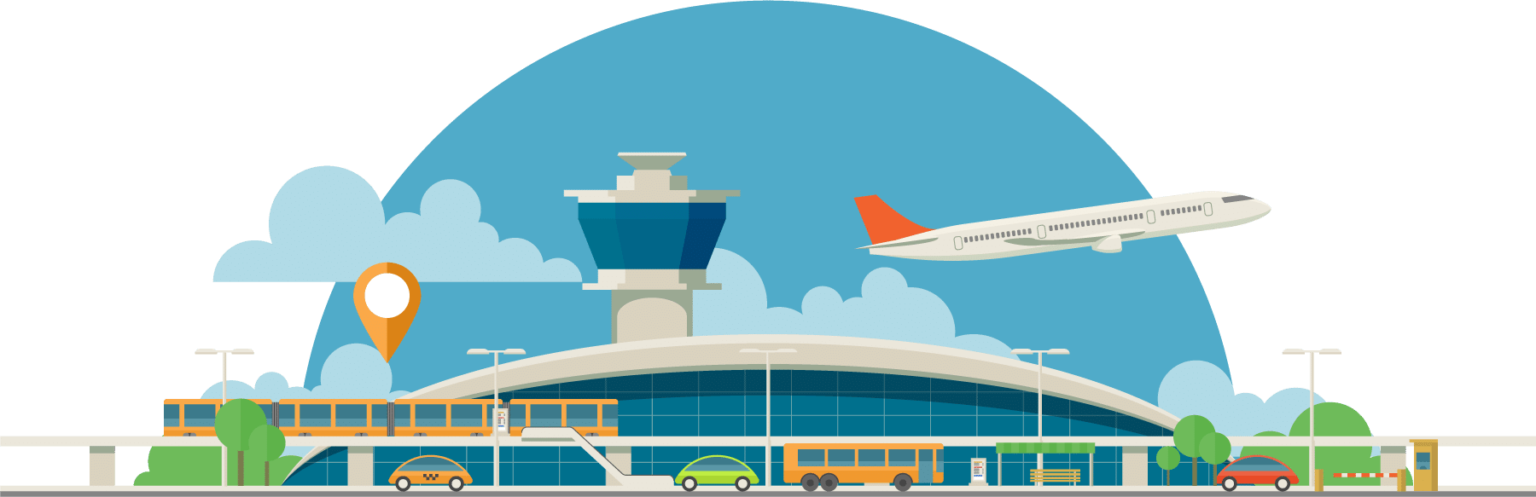

In [2]:
# установка всех библиотек, необходимых для выполнения ДЗ

!pip install catboost
!pip install mlxtend --upgrade
!pip install optuna
!pip install lime
!pip install shap
!pip install missingno
!pip install psycopg2-binary
#!pip install xgboost
#!brew install cmake libomp
#!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 65.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: scikit-learn
    Found existing installation: s

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 19.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 15.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=92d4dbc9fabbe5d6d50715a120561e404264d08d70085916f7f0c086971d2d54
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 74.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.1
    Uninstalling numpy-2.4.1:
      Successfully uninstalled numpy-2.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.24.0 requires numpy>=2.3.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 71.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import missingno

import psycopg2
import psycopg2.extras

from mlxtend.plotting import plot_decision_regions
from mlxtend.evaluate import bias_variance_decomp
from graphviz import Source
from sklearn.tree import export_graphviz
from IPython.display import SVG

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.calibration import CalibrationDisplay
from sklearn.isotonic import IsotonicRegression

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, mutual_info_classif
from sklearn.feature_selection import SequentialFeatureSelector, RFE, SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator

import shap
import lime
import lime.lime_tabular

import optuna

import pickle

np.random.seed(42)

# **Часть 1: Получение данных, обработка и EDA (2.75 балла)**

В этой части вам необходимо:
- Загрузить данные из БД и предобработать их (1.75 бала)
- Провести разведочный анализ данных (1. балл)

## **1. 1. Загрузка и предобработка данных (1.75 балла)**

In [4]:
!mkdir -p ~/.postgresql && \
wget "https://storage.yandexcloud.net/cloud-certs/CA.pem" \
    --output-document ~/.postgresql/root.crt && \
chmod 0600 ~/.postgresql/root.crt

--2026-01-27 13:40:43--  https://storage.yandexcloud.net/cloud-certs/CA.pem
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3579 (3.5K) [application/x-x509-ca-cert]
Saving to: ‘/root/.postgresql/root.crt’

/root/.postgresql/r 100%[===================>]   3.50K  --.-KB/s    in 0s      

2026-01-27 13:40:45 (1.10 GB/s) - ‘/root/.postgresql/root.crt’ saved [3579/3579]



### **Задание 1. Получение данных (0.5 балла)**

- Подключитесь к БД при помощи `psycopg2.connect()`
- Напишите SQL-запрос, объединяющий 3 нужные таблицы в одну
- Результат запроса поместите в `pd.DataFrame`. Индексом получившегося датафрейма сделайте столбец 'id'.

Список столбцов таблиц добудьте самостоятельно.


**Примечание:**
 Не забудьте закрыть соединение. Или открывайте соединение, используя менеджер контекста `with as`, который закроет его автоматически

##### **Параметры соединения:**
```
host=rc1b-70q90cunwkzx49mj.mdb.yandexcloud.net
port=6432
sslmode=verify-full
dbname=db_flights
user=mlhs_student
password=mlhs_student
target_session_attrs=read-write```
```

##### **Схема БД**

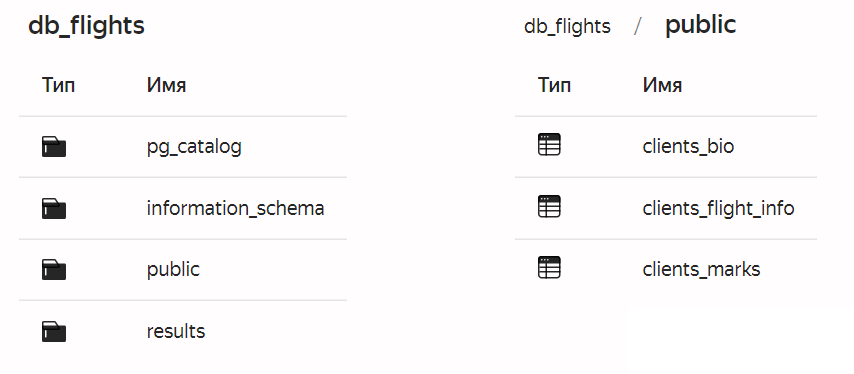



In [5]:
import psycopg2
import psycopg2.extras
from psycopg2.extras import RealDictCursor
conn_params = {
    'host': 'rc1b-70q90cunwkzx49mj.mdb.yandexcloud.net',
    'port': 6432,
    'sslmode': 'verify-full',
    'dbname': 'db_flights',
    'user': 'mlhs_student',
    'password': 'mlhs_student',
    'target_session_attrs': 'read-write'
}

try:
    with psycopg2.connect(**conn_params) as conn:
        with conn.cursor(cursor_factory=RealDictCursor) as cursor:

            query = """
            SELECT
                cb.*,
                cfi.*,
                cm.*
            FROM clients_bio cb
            JOIN clients_flight_info cfi ON cb.id = cfi.id
            JOIN clients_marks cm ON cb.id = cm.id
            ORDER BY cb.id;
            """

            cursor.execute(query)
            result = cursor.fetchall()

            df = pd.DataFrame(result)

            if 'id' in df.columns:
                df.set_index('id', inplace=True)

                df = df[~df.index.duplicated(keep='first')]
                print(f" Форма (строки, колонки): {df.shape}")
                print("\nПервые 3 строки данных:")
                print(df.head(3))
            else:
                print("Ошибка: столбец 'id' не найден в результате")

except psycopg2.Error as e:
    print(f"Ошибка подключения к базе данных: {e}")
except Exception as e:
    print(f"Произошла ошибка: {e}")


 Форма (строки, колонки): (129549, 23)

Первые 3 строки данных:
    gender   age      Customer Type   Type of Travel     class  \
id                                                               
1     Male  48.0  disloyal Customer  Business travel  Business   
2   Female  35.0     Loyal Customer  Business travel  Business   
3     Male  41.0     Loyal Customer  Business travel  Business   

   Flight Distance Departure Delay in Minutes Arrival Delay in Minutes  \
id                                                                       
1            821.0                        2.0                      5.0   
2            821.0                       26.0                     39.0   
3            853.0                        0.0                      0.0   

   Inflight wifi service Departure/Arrival time convenient  ...  \
id                                                          ...   
1                    3.0                               3.0  ...   
2                    2.0         

In [6]:
assert df.shape == (129_549, 23)

### **Задание 2 (0.25 балла)**

- Преобразуйте числовые столбцы в `float`. Проверьте, есть ли в датафрейме пропуски и выбросы (в том числе в категориальных признаках)</font>.

In [7]:
# Столбцы, которые точно являются категориальными
categorical_columns = [
    'gender',
    'Customer Type',
    'Type of Travel',
    'class',
    'satisfaction'
]

# Столбцы, которые должны быть числовыми
numerical_columns = [
    'age',
    'Flight Distance',
    'Departure Delay in Minutes',
    'Arrival Delay in Minutes',
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'cleanliness'
]

# Преобразуем числовые столбцы в float
for col in numerical_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype(float)

# Очищаем категориальные столбцы
for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace('nan', np.nan)
        df[col] = df[col].replace('', np.nan)

print("Типы данных после преобразования:")
print(df.dtypes)

# Проверяем пропущенные значения
missing_total = df.isnull().sum().sum()
print(f"\nОбщее количество пропусков: {missing_total}")

if missing_total > 0:
    missing_by_col = df.isnull().sum()
    cols_with_missing = missing_by_col[missing_by_col > 0]

    print(f"Столбцы с пропусками ({len(cols_with_missing)}):")
    for col, count in cols_with_missing.items():
        percentage=(count/len(df))* 100
        print(f"- {col}: {count} пропусков ({percentage}%)")

# Проверяем уникальные значения в категориальных столбцах
for col in categorical_columns:
    if col in df.columns:
        unique_vals = df[col].dropna().unique()
        print(f"\n   {col}:")
        print(f" Уникальных значений: {len(unique_vals)}")
        if len(unique_vals)<= 10:
            print(f" Значения: {sorted(unique_vals)}")

        value_counts = df[col].value_counts(dropna=False)
        total = value_counts.sum()

        rare_values = value_counts[value_counts / total < 0.001]
        if len(rare_values) > 0:
            print(f"  Редкие значения (меньше 0.1%): {len(rare_values)}")
            for val, count in rare_values.head(5).items():
                print(f" '{val}': {count} раз")

# Проверяем выбросы в числовых столбцах
print("Проверка выбросов в числовых столбцах:")
for col in numerical_columns:
    if col in df.columns and df[col].dtype in [np.float64, np.int64]:
        Q1= df[col].quantile(0.25)
        Q3= df[col].quantile(0.75)
        IQR= Q3 -Q1

        lower_bound =Q1-1.5*IQR
        upper_bound= Q3+ 1.5*IQR
        outliers= df[(df[col]<lower_bound) | (df[col]>upper_bound)]
        outliers_count= len(outliers)

        if outliers_count>0:
            percentage= (outliers_count /len(df))*100
            print(f"\n   {col}:")
            print(f" Выбросов: {outliers_count} ({percentage}%)")


Типы данных после преобразования:
gender                                   str
age                                  float64
Customer Type                            str
Type of Travel                           str
class                                    str
Flight Distance                      float64
Departure Delay in Minutes           float64
Arrival Delay in Minutes             float64
Inflight wifi service                float64
Departure/Arrival time convenient    float64
Ease of Online booking               float64
Gate location                        float64
Food and drink                       float64
Online boarding                      float64
Seat comfort                         float64
Inflight entertainment               float64
On-board service                     float64
Leg room service                     float64
Baggage handling                     float64
Checkin service                      float64
Inflight service                     float64
cleanliness          

### **Задание 3 (0.5 балла)**

Воспользуйтесь модулем `missingno` для визуализации пропусков в датафрейме. Постройте:
-  `matrix` пропущенных значений;
- столбчатую диаграмму в **логарифмированной** шкале (так как пропусков немного, по обычной не будет видно, в каких столбцах их больше)

<Figure size 1200x800 with 0 Axes>

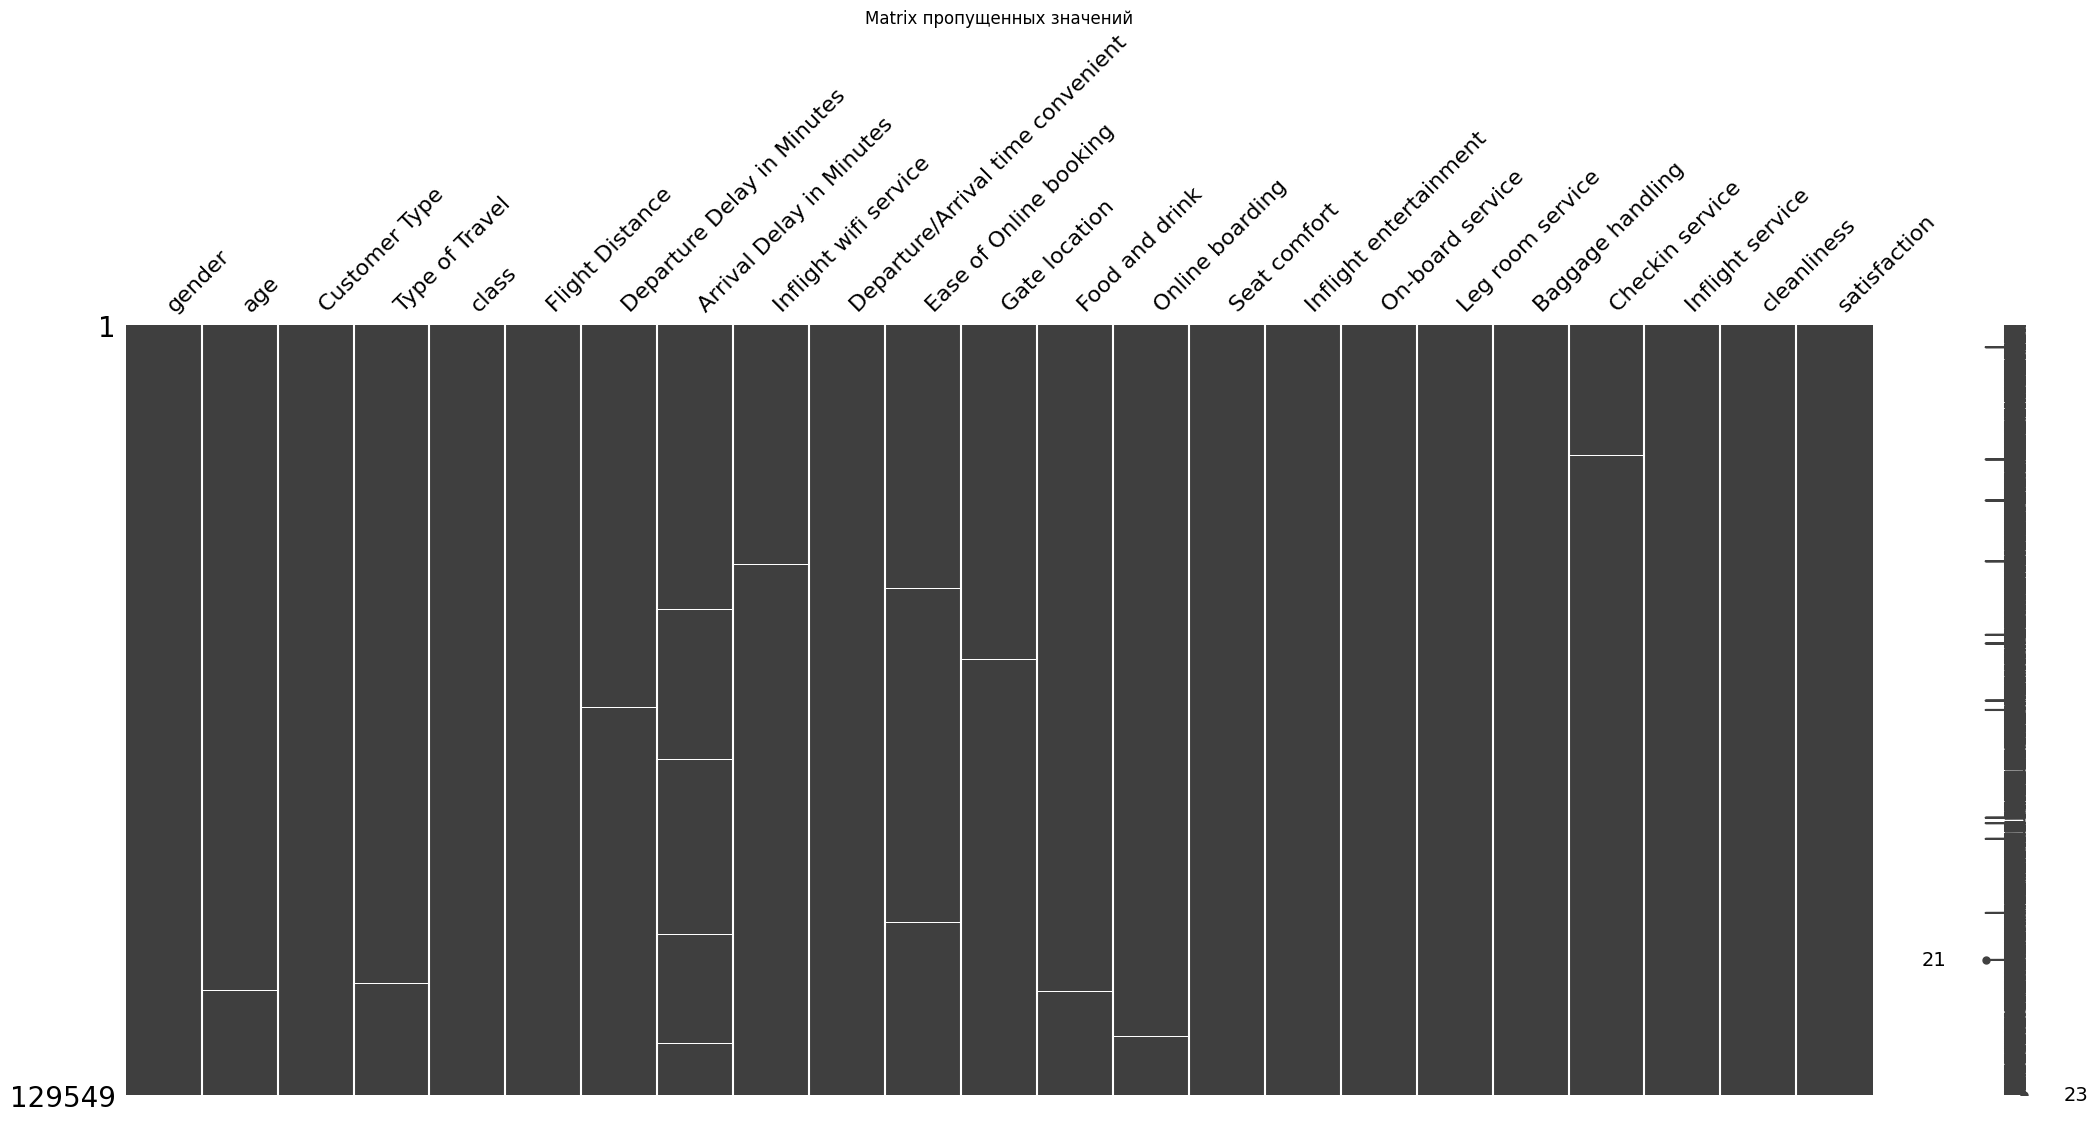

In [8]:
import missingno as msno

# Matrix пропущенных значений
plt.figure(figsize=(12, 8))
msno.matrix(df)
plt.title('Matrix пропущенных значений')
plt.show()



/usr/local/lib/python3.12/dist-packages/missingno/missingno.py:271: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([int(n * len(df)) for n in ax1.get_yticks()], fontsize=fontsize)


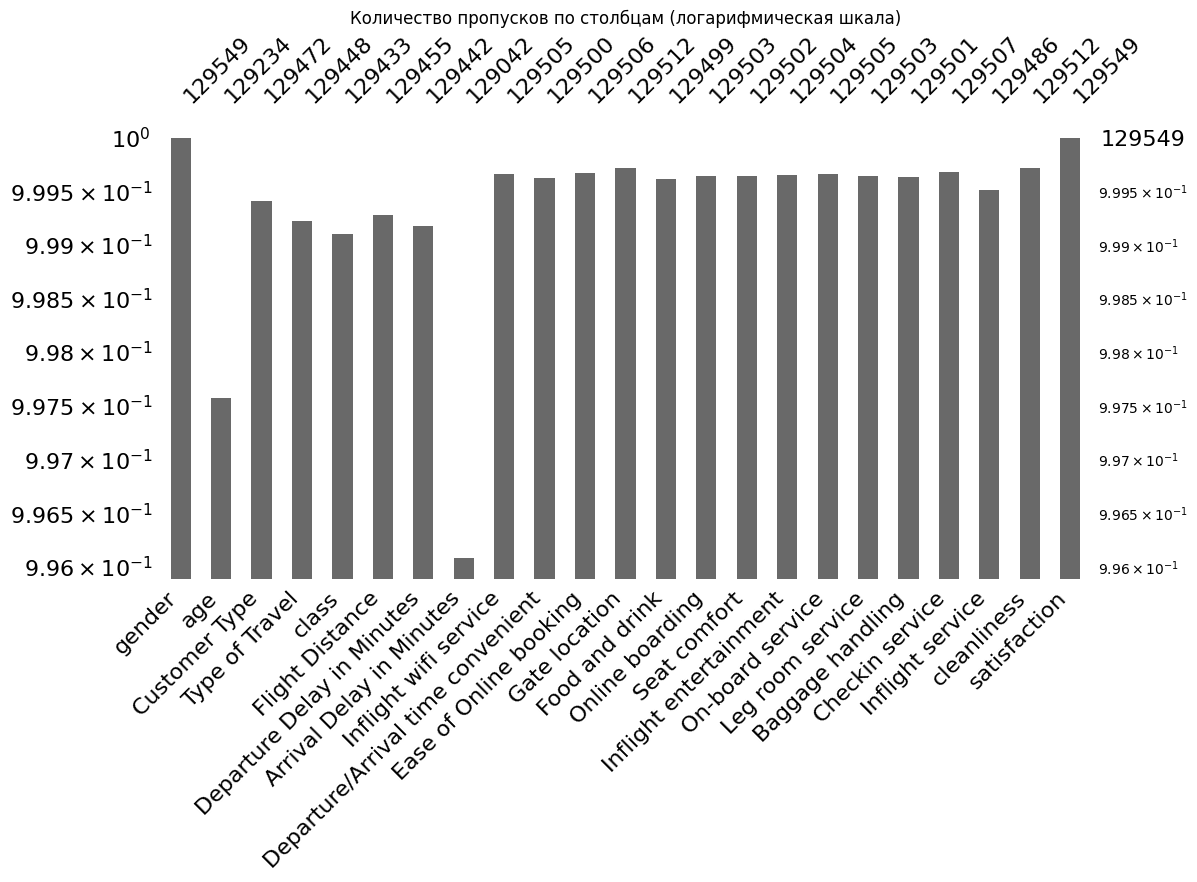

In [9]:
# Столбчатая диаграмма в логарифмической шкале
plt.figure(figsize=(12, 6))
msno.bar(df, log=True, figsize=(12, 6))
plt.title('Количество пропусков по столбцам (логарифмическая шкала)')
plt.show()




Разобьем датасет на тренировочную и тестовую части. Тестовую часть отложим надолго -- до самого конца этого ноутбука.

In [10]:
df_train = df[df.satisfaction != '-']
df_train

,gender,age,Customer Type,Type of Travel,class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,...,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,cleanliness,satisfaction
id,,,,,,,,,,,,,,,,,,,,,
1,Male,48.0,disloyal Customer,Business travel,Business,821.0,2.0,5.0,3.0,3.0,...,3.0,5.0,5.0,3.0,2.0,5.0,4.0,5.0,5.0,neutral or dissatisfied
2,Female,35.0,Loyal Customer,Business travel,Business,821.0,26.0,39.0,2.0,2.0,...,5.0,4.0,5.0,5.0,5.0,5.0,3.0,5.0,5.0,satisfied
3,Male,41.0,Loyal Customer,Business travel,Business,853.0,0.0,0.0,4.0,4.0,...,5.0,5.0,3.0,3.0,3.0,3.0,4.0,3.0,5.0,satisfied
4,Male,50.0,Loyal Customer,Business travel,Business,1905.0,0.0,0.0,2.0,2.0,...,4.0,5.0,5.0,5.0,5.0,5.0,3.0,5.0,4.0,satisfied
5,Female,49.0,Loyal Customer,Business travel,Business,3470.0,0.0,1.0,3.0,3.0,...,5.0,4.0,3.0,3.0,4.0,3.0,3.0,3.0,5.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129874,Female,28.0,Loyal Customer,Personal Travel,Eco Plus,337.0,0.0,0.0,4.0,2.0,...,4.0,3.0,3.0,1.0,5.0,3.0,4.0,4.0,3.0,neutral or dissatisfied
129875,Female,55.0,Loyal Customer,Personal Travel,Eco Plus,308.0,0.0,0.0,3.0,4.0,...,4.0,3.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,neutral or dissatisfied
129878,Male,42.0,Loyal Customer,Personal Travel,Eco Plus,337.0,6.0,14.0,2.0,5.0,...,2.0,3.0,3.0,3.0,4.0,5.0,4.0,4.0,3.0,neutral or dissatisfied


In [11]:
assert df_train.shape == (103_644, 23)

In [12]:
df_test = df[df.satisfaction == '-'].drop('satisfaction', axis=1)
df_test

,gender,age,Customer Type,Type of Travel,class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,...,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,cleanliness
id,,,,,,,,,,,,,,,,,,,,,
17,Female,48.0,Loyal Customer,Personal Travel,Eco,821.0,0.0,0.0,2.0,3.0,...,1.0,5.0,1.0,5.0,5.0,2.0,5.0,5.0,5.0,2.0
20,Female,42.0,Loyal Customer,Personal Travel,Eco,821.0,4.0,0.0,3.0,3.0,...,1.0,3.0,4.0,1.0,1.0,3.0,1.0,3.0,1.0,3.0
35,Male,39.0,Loyal Customer,Business travel,Business,1672.0,23.0,17.0,2.0,2.0,...,5.0,4.0,5.0,3.0,3.0,4.0,5.0,5.0,3.0,5.0
44,Male,51.0,Loyal Customer,Business travel,Business,2077.0,0.0,1.0,4.0,1.0,...,2.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0
49,Male,20.0,disloyal Customer,Business travel,Eco,108.0,0.0,29.0,4.0,5.0,...,5.0,4.0,3.0,5.0,5.0,4.0,5.0,5.0,4.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129847,Female,16.0,Loyal Customer,Personal Travel,Eco,337.0,0.0,0.0,0.0,4.0,...,3.0,0.0,3.0,3.0,5.0,2.0,4.0,4.0,5.0,3.0
129868,Male,47.0,Loyal Customer,Business travel,Eco Plus,447.0,0.0,0.0,3.0,4.0,...,4.0,3.0,4.0,4.0,2.0,5.0,3.0,1.0,4.0,4.0
129872,Female,32.0,Loyal Customer,Business travel,Eco Plus,337.0,0.0,1.0,4.0,2.0,...,4.0,4.0,4.0,4.0,5.0,1.0,3.0,5.0,1.0,4.0


In [13]:
assert df_test.shape == (25_905, 22)

Разбиваем данные на трейн и валидацию. Не меняйте сид

In [14]:
X_train, X_val, y_train, y_val = train_test_split(df_train.drop('satisfaction', axis=1), df_train.satisfaction, test_size=0.3, random_state=42)

In [15]:
assert X_train.shape == (72_550, 22)
assert X_val.shape == (31_094, 22)

### **Задание 4. (0.15 балла)**

Заполните пропуски в данных наиболее часто встречающимся значением.
Помните про правильность заполнения.

**Примечание:** Мы также могли восстановать пропуски `KNNImputer`'ом или `IterativeImputer`'ом. Как правило, такое заполнение точнее и лучше сохраняет структуру распределений. Но для признаков в нашей задаче Imputer'ы, реализованные библиотечно не подошли бы. Они возвращали бы вещественные значения, а в нашей задаче все признаки целые.

In [16]:
print('Пропуски в исходных данных')
print("X_train:", X_train.isnull().sum().sum())
print("X_val:", X_val.isnull().sum().sum())

imputer_mode = SimpleImputer(strategy='most_frequent')

X_train_filled = pd.DataFrame(
    imputer_mode.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_val_filled = pd.DataFrame(
    imputer_mode.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

print("\nПропуски после заполнения:")
print("X_train_filled:", X_train_filled.isnull().sum().sum())
print("X_val_filled:", X_val_filled.isnull().sum().sum())


Пропуски в исходных данных
X_train: 1091
X_val: 479

Пропуски после заполнения:
X_train_filled: 0
X_val_filled: 0


### **Задание 5. (0.1 балла)**

- Выведите основные статистики по числовым и категориальным столбцам таблицы
- Сделайте **текстовый** вывод о распределениях значений признаков

In [17]:
print("Числовые характеристики")
print(df_train.describe())

print("\nКатегориальные характеристики")
print(df_train.describe(include=['object', 'category']))

print("\nРаспределение по категориям")
cat_cols = ['gender', 'Customer Type', 'Type of Travel', 'class', 'satisfaction']
for col in cat_cols:
    print(df_train[col].value_counts())


Числовые характеристики
                 age  Flight Distance  Departure Delay in Minutes  \
count  103383.000000    103572.000000               103560.000000   
mean       40.058598      1325.940582                   15.814455   
std        20.357517      4653.636096                   73.965629   
min         0.000000         0.000000                    0.000000   
25%        27.000000       414.000000                    0.000000   
50%        40.000000       844.500000                    0.000000   
75%        51.000000      1744.000000                   12.000000   
max       612.000000    379620.000000                11011.000000   

       Arrival Delay in Minutes  Inflight wifi service  \
count             103239.000000          103612.000000   
mean                  16.779279               2.733255   
std                  109.194016               1.358142   
min                    0.000000               0.000000   
25%                    0.000000               2.000000   
50%   

/tmp/ipython-input-4211846245.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_train.describe(include=['object', 'category']))


**Выводы по числовым признакам: **
1. Возраст (age):
*  Средний возраст: 40.1 лет
* Минимальный: 0 лет
* Максимальный: 621 лет - ЯВНАЯ ОШИБКА В ДАННЫХ

2. Flight Distance:
* Среднее расстояние: 1,323 км
* Максимальное: 379,620 км - ЯВНАЯ ОШИБКА! (Сильно увеличивает среднее расстояние)
* 50% полетов: 414-1,744 км
   
3. Departure Delay:
* Среднее: 15.8 минут
* Максимальное: 22,227 минут - ВЫБРОС (увеличивает среднее количество минут задержки)
* 75% рейсов: задержка до 12 минут
     
4. Arrival Delay:
* Среднее: 16.7 минут
* Максимальное: 14,006 минут (233 часа!) - ВЫБРОС
* Медиана: 0 минут (половина рейсов без задержек)

5. Оценки сервисов (шкала 0-5, но есть аномалии до 45):
 * Все оценки имеют похожее распределение
 * Средние оценки: 2.7-3.6 из 5
   
   Самые высокие оценки: (Baggage handling - 3.64, Inflight service - 3.65)
   
   Самые низкие оценки: (Inflight wifi service - 2.73, Ease of Online booking - 2.76)
   
Проблемы с данными - Максимальные значения до 45 (вместо ожидаемых 5)

Выводы по категориальным признакам:

1. Гендерное распределение (gender) - равномерное
2. Тип клиента (Customer Type) - преобладают лояльные клиенты
3. Цель поездки (Type of Travel) - большинство поездок являются деловыми
4. Класс обслуживания (class) - Преобладают Business и Eco классы
5. Удовлетворенность (satisfaction) - Больше неудовлетворенных клиентов


### **Задание 6 (0.25 балла)**

- Удалите строки c выбросами в числовых столбцах (для трейна и валидации; тест оставьте без изменений).

**Примечание:** Выбросами считайте значения признака, строго превышающие 0.996-квантиль.

По определению, квантиль — значение, которое заданная случайная величина не превышает с фиксированной вероятностью. То есть, если мы смотрим на квантиль 0.996-квантиль, то значения после этого квантиля встречаются в 0.004% случаев. В среднем для всех признаков эти значения начинаются ~в этом квантиле.



In [18]:
def remove_outliers_quantile(df, columns, quantile=0.996):
    mask = pd.Series([True] * len(df), index=df.index)

    for col in columns:
        if col in df.columns:
            threshold = df[col].quantile(quantile)
            mask &= (df[col] <= threshold)

    return df[mask]

# Применяем к train и validation
X_train_clean = remove_outliers_quantile(X_train, numerical_columns)
X_val_clean = remove_outliers_quantile(X_val, numerical_columns)

print(f"Размер train до очистки: {len(X_train)}")
print(f"Размер train после: {len(X_train_clean)}")
print(f"Удалено строк: {len(X_train) - len(X_train_clean)}")

Размер train до очистки: 72550
Размер train после: 70470
Удалено строк: 2080


In [19]:
X_train=X_train_clean
X_val=X_val_clean

In [20]:
assert df_test.shape == (25_905, 22)

## **1. 2. EDA (1 балл)**

Создадим переменные с перечислениями столбцов разного типа

In [21]:
continuous_cols = ['age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
ordinal_cols = list(set(df.select_dtypes(include='number').columns) - set(continuous_cols))
categorical_cols = list(df.select_dtypes(include='object').columns)[:-1]

/tmp/ipython-input-1013457405.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = list(df.select_dtypes(include='object').columns)[:-1]


In [22]:
assert len(continuous_cols + ordinal_cols + categorical_cols) == 22

### **Задание 7. (0.3 балла)**

- Напишите процедуры для отрисовки графиков;
 * Для признаков, которые мы выделили как порядковые и для категориальных, отображайте только `countplot`
  * Для тех, что считаем континуальными, -- гистограмму распределения признака и ящик с усами (inline)

- Вызовите все 3 написанные процедуры для соответствующих колонок `X_train`. Отдельно визуализируйте распределение таргета в трейне. Всё должно красиво работать! :)

**Примечание 1:**

Помните про хороший тон визуализации — все графики и их оси обязательно должны быть подписаны, легенда на графике также необходима! За неё также могут быть сняты баллы.

**Примечание 2:**

Обязательно выделяйте таргет разными цветами. Мы же хотим в конечном итоге понять, чем удовлетворенные клиенты отличаются от недовольных.

In [23]:
def plot_ordinal(cols, df, y):
    """Draws countplots for all columns in 'cols' with informative title"""
    n_cols = len(cols)
    n_cols_per_row = 3
    n_rows = (n_cols + n_cols_per_row - 1) // n_cols_per_row

    fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(18, 6*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    else:
        axes = np.array(axes).ravel()

    for i, col in enumerate(cols):
        ax = axes[i] if n_rows * n_cols_per_row > i else axes[i % len(axes)]
        sns.countplot(data=df, x=col, hue=y, ax=ax, palette=['lightcoral', 'lightgreen'])
        ax.set_title(f'{col} по удовлетворённости', fontsize=12, fontweight='bold')
        ax.set_xlabel(col, fontsize=10)
        ax.set_ylabel('Количество', fontsize=10)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(title='Удовлетворённость', title_fontsize=10)

    plt.tight_layout()
    plt.show()



In [24]:
def plot_continuous(cols, df, y):
    """Draws kdeplots and boxplots in one row
    for all columns in 'cols' with informative title
    """
    fig, axes = plt.subplots(len(cols), 2, figsize=(15, 5*len(cols)))

    for i, col in enumerate(cols):
        for satisfaction_level in y.unique():
            mask = y == satisfaction_level
            axes[i, 0].hist(df.loc[mask, col], bins=30, alpha=0.6,
                          label=f'{satisfaction_level}', density=True)
        sns.kdeplot(data=df, x=col, hue=y, ax=axes[i, 0], fill=True,
                   common_norm=False, palette=['lightcoral', 'lightgreen'])
        axes[i, 0].set_title(f'Распределение {col}', fontsize=12, fontweight='bold')
        axes[i, 0].set_xlabel(col, fontsize=10)
        axes[i, 0].set_ylabel('Плотность', fontsize=10)
        axes[i, 0].legend(title='Удовлетворённость', title_fontsize=10)

        sns.boxplot(data=df, x=y, y=col, ax=axes[i, 1],
                   palette=['lightcoral', 'lightgreen'])
        axes[i, 1].set_title(f'Ящик с усами {col}', fontsize=12, fontweight='bold')
        axes[i, 1].set_xlabel('Удовлетворённость', fontsize=10)
        axes[i, 1].set_ylabel(col, fontsize=10)

    plt.tight_layout()
    plt.show()

In [25]:
def plot_categorical(cols, df, y):
    """Draws countplots for all columns in 'cols' with informative title"""
    n_cols = len(cols)
    fig, axes = plt.subplots(1, n_cols, figsize=(6*n_cols, 6))
    if n_cols == 1:
        axes = [axes]

    for i, col in enumerate(cols):
        sns.countplot(data=df, x=col, hue=y, ax=axes[i],
                     palette=['lightcoral', 'lightgreen'])
        axes[i].set_title(f'{col} по удовлетворённости', fontsize=14, fontweight='bold')
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('Количество', fontsize=12)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(title='Удовлетворённость', title_fontsize=11)

    plt.tight_layout()
    plt.show()

Отрисовка.

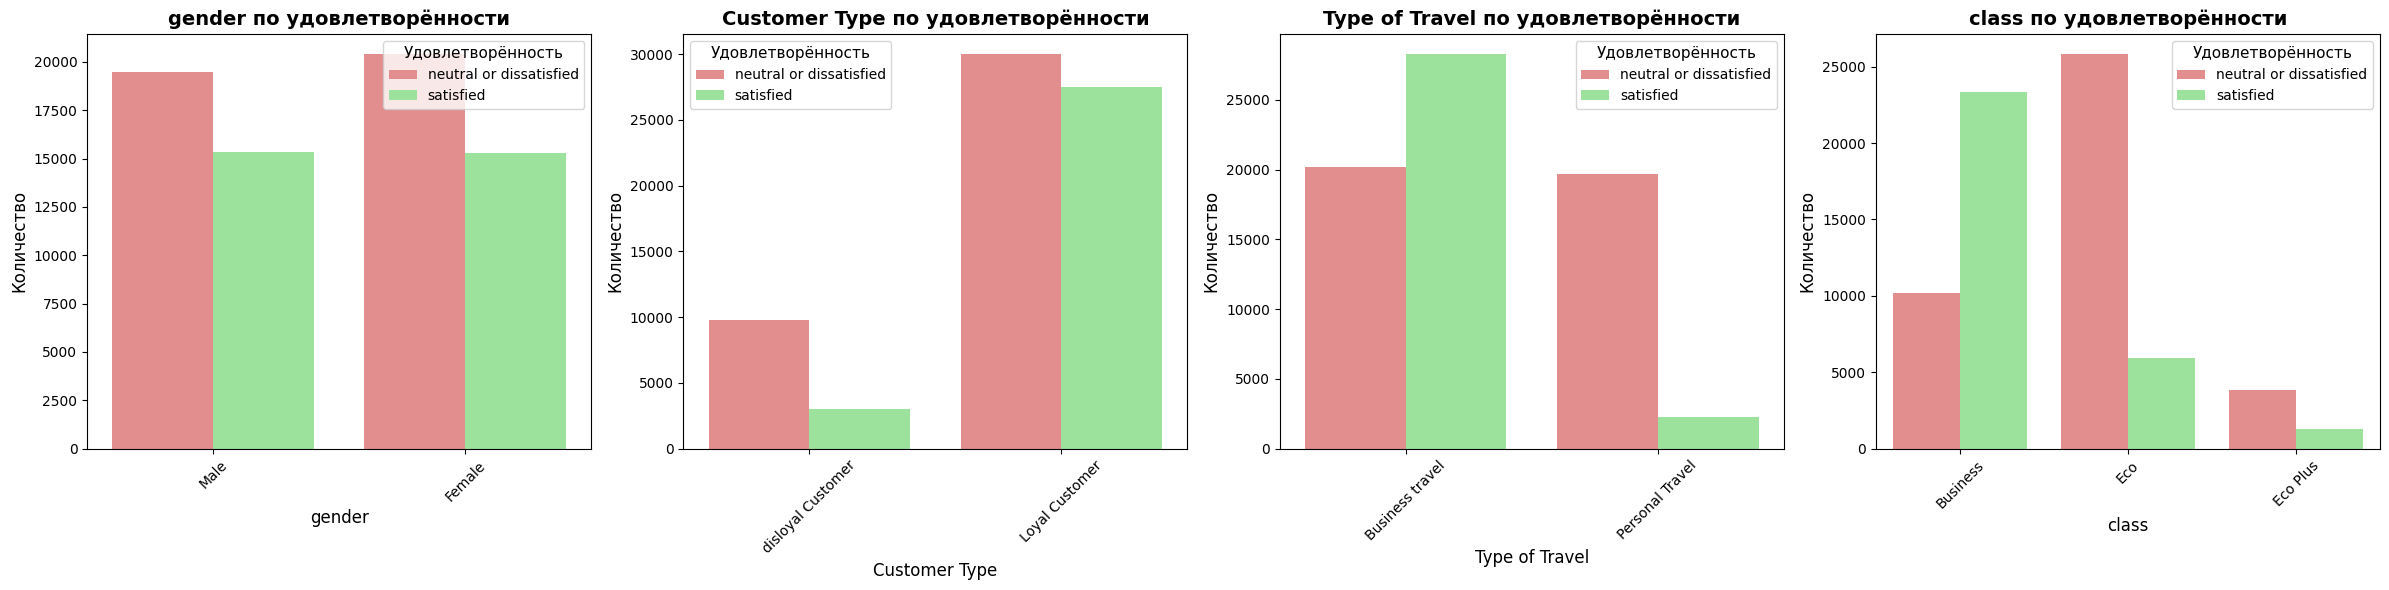

In [26]:
plot_categorical(categorical_cols, X_train, y_train)

/tmp/ipython-input-3203596686.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=y, y=col, ax=axes[i, 1],
/tmp/ipython-input-3203596686.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=y, y=col, ax=axes[i, 1],
/tmp/ipython-input-3203596686.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=y, y=col, ax=axes[i, 1],
/tmp/ipython-input-3203596686.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend

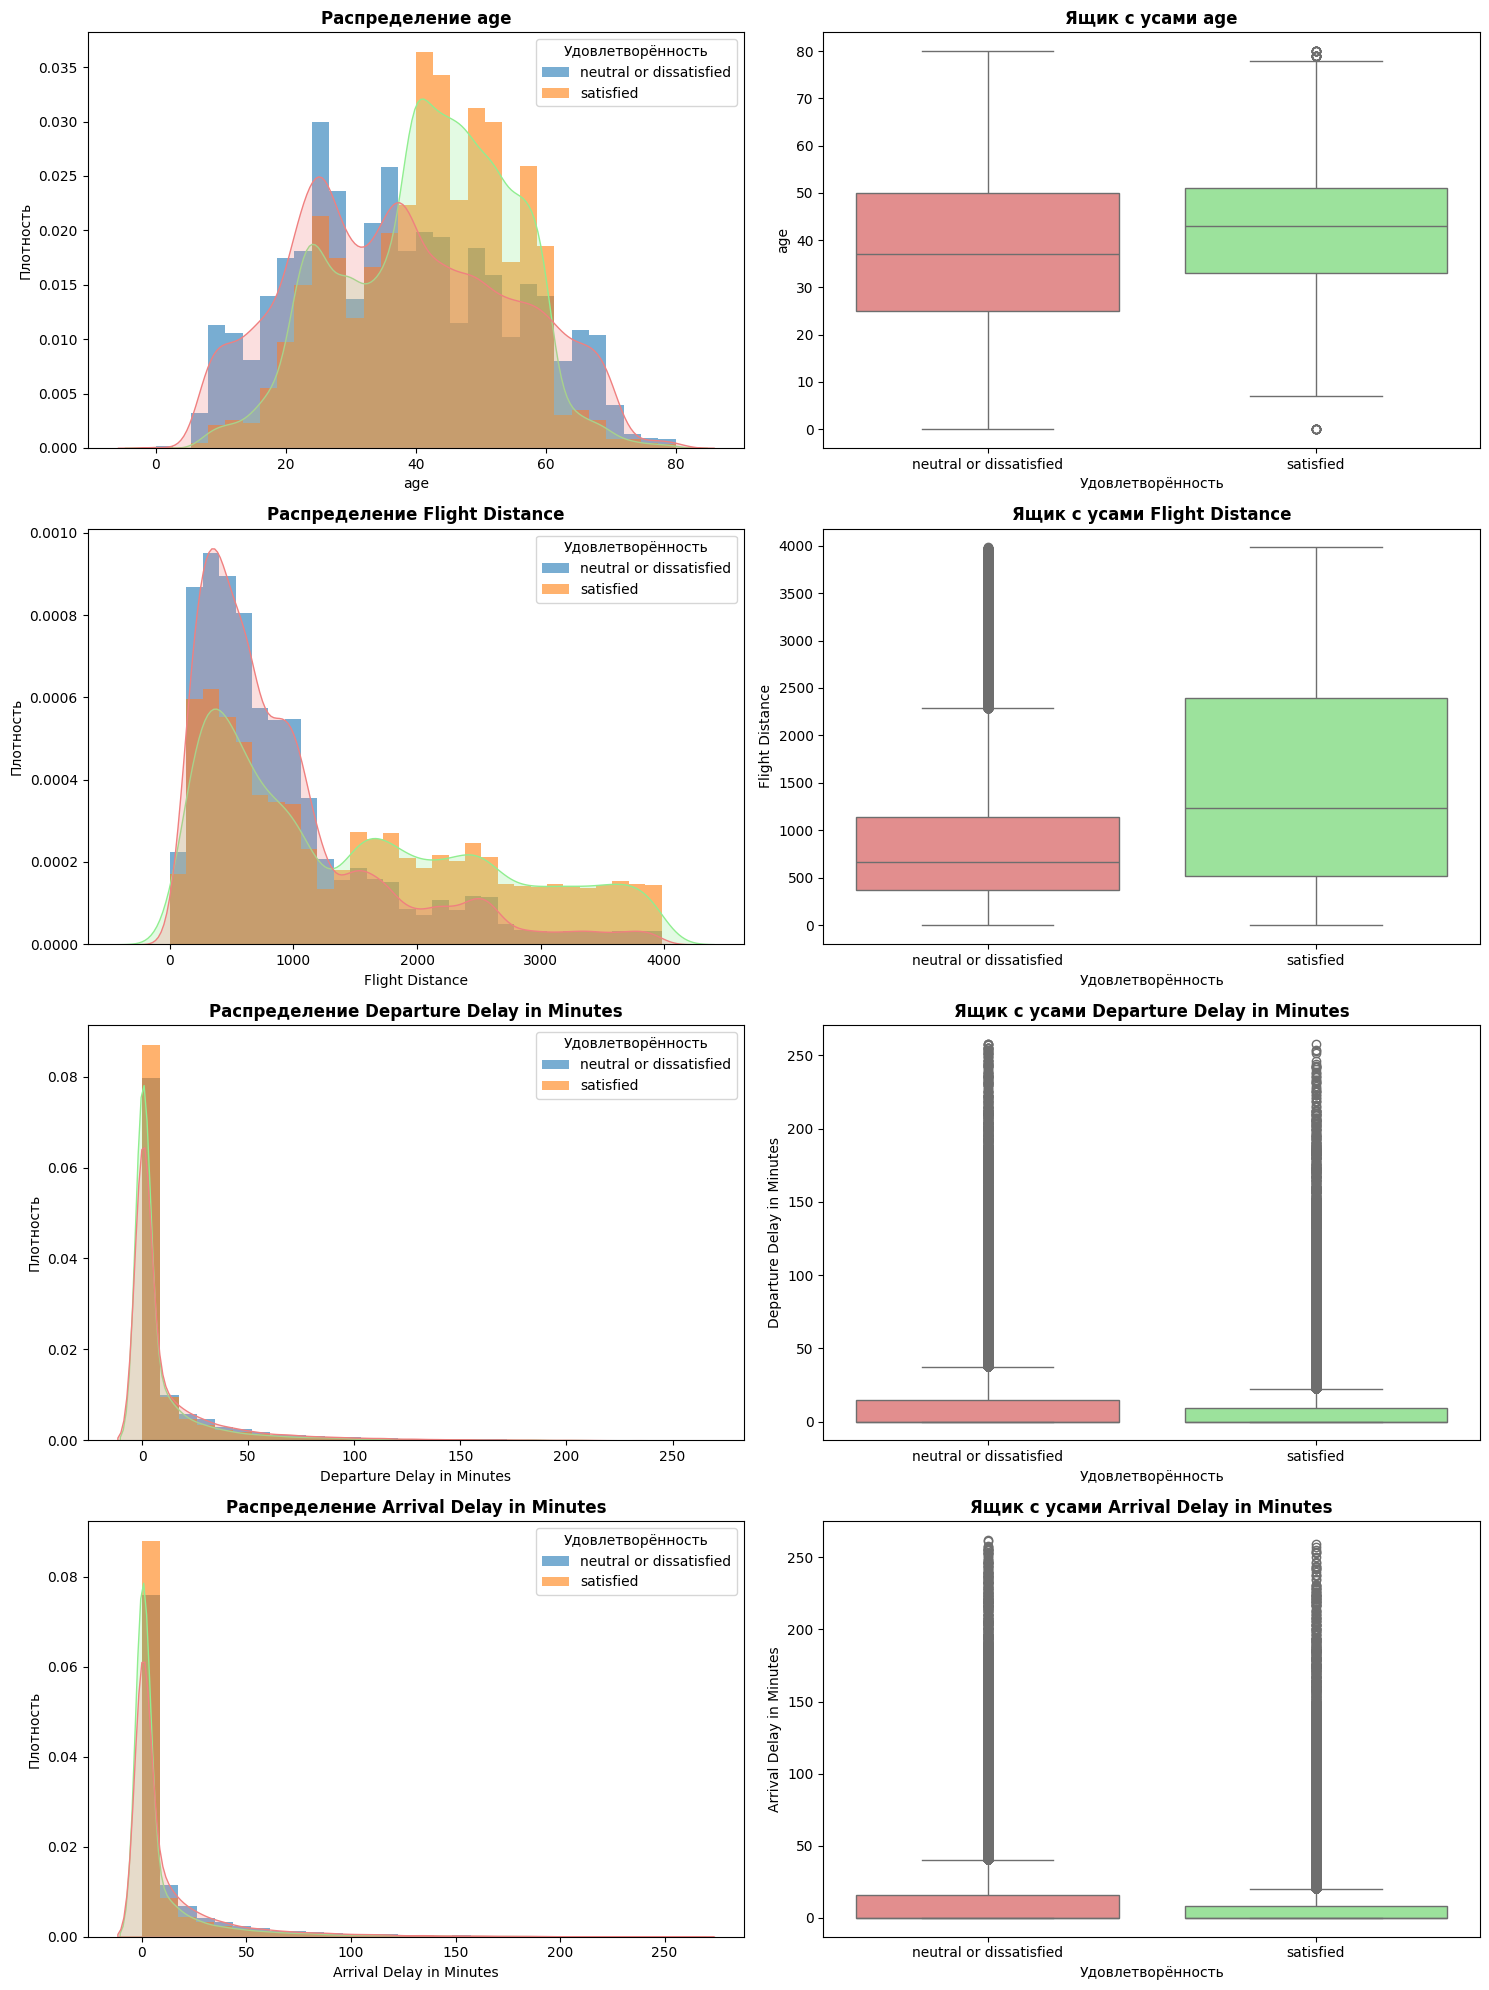

In [37]:
plot_continuous(continuous_cols, X_train, y_train)

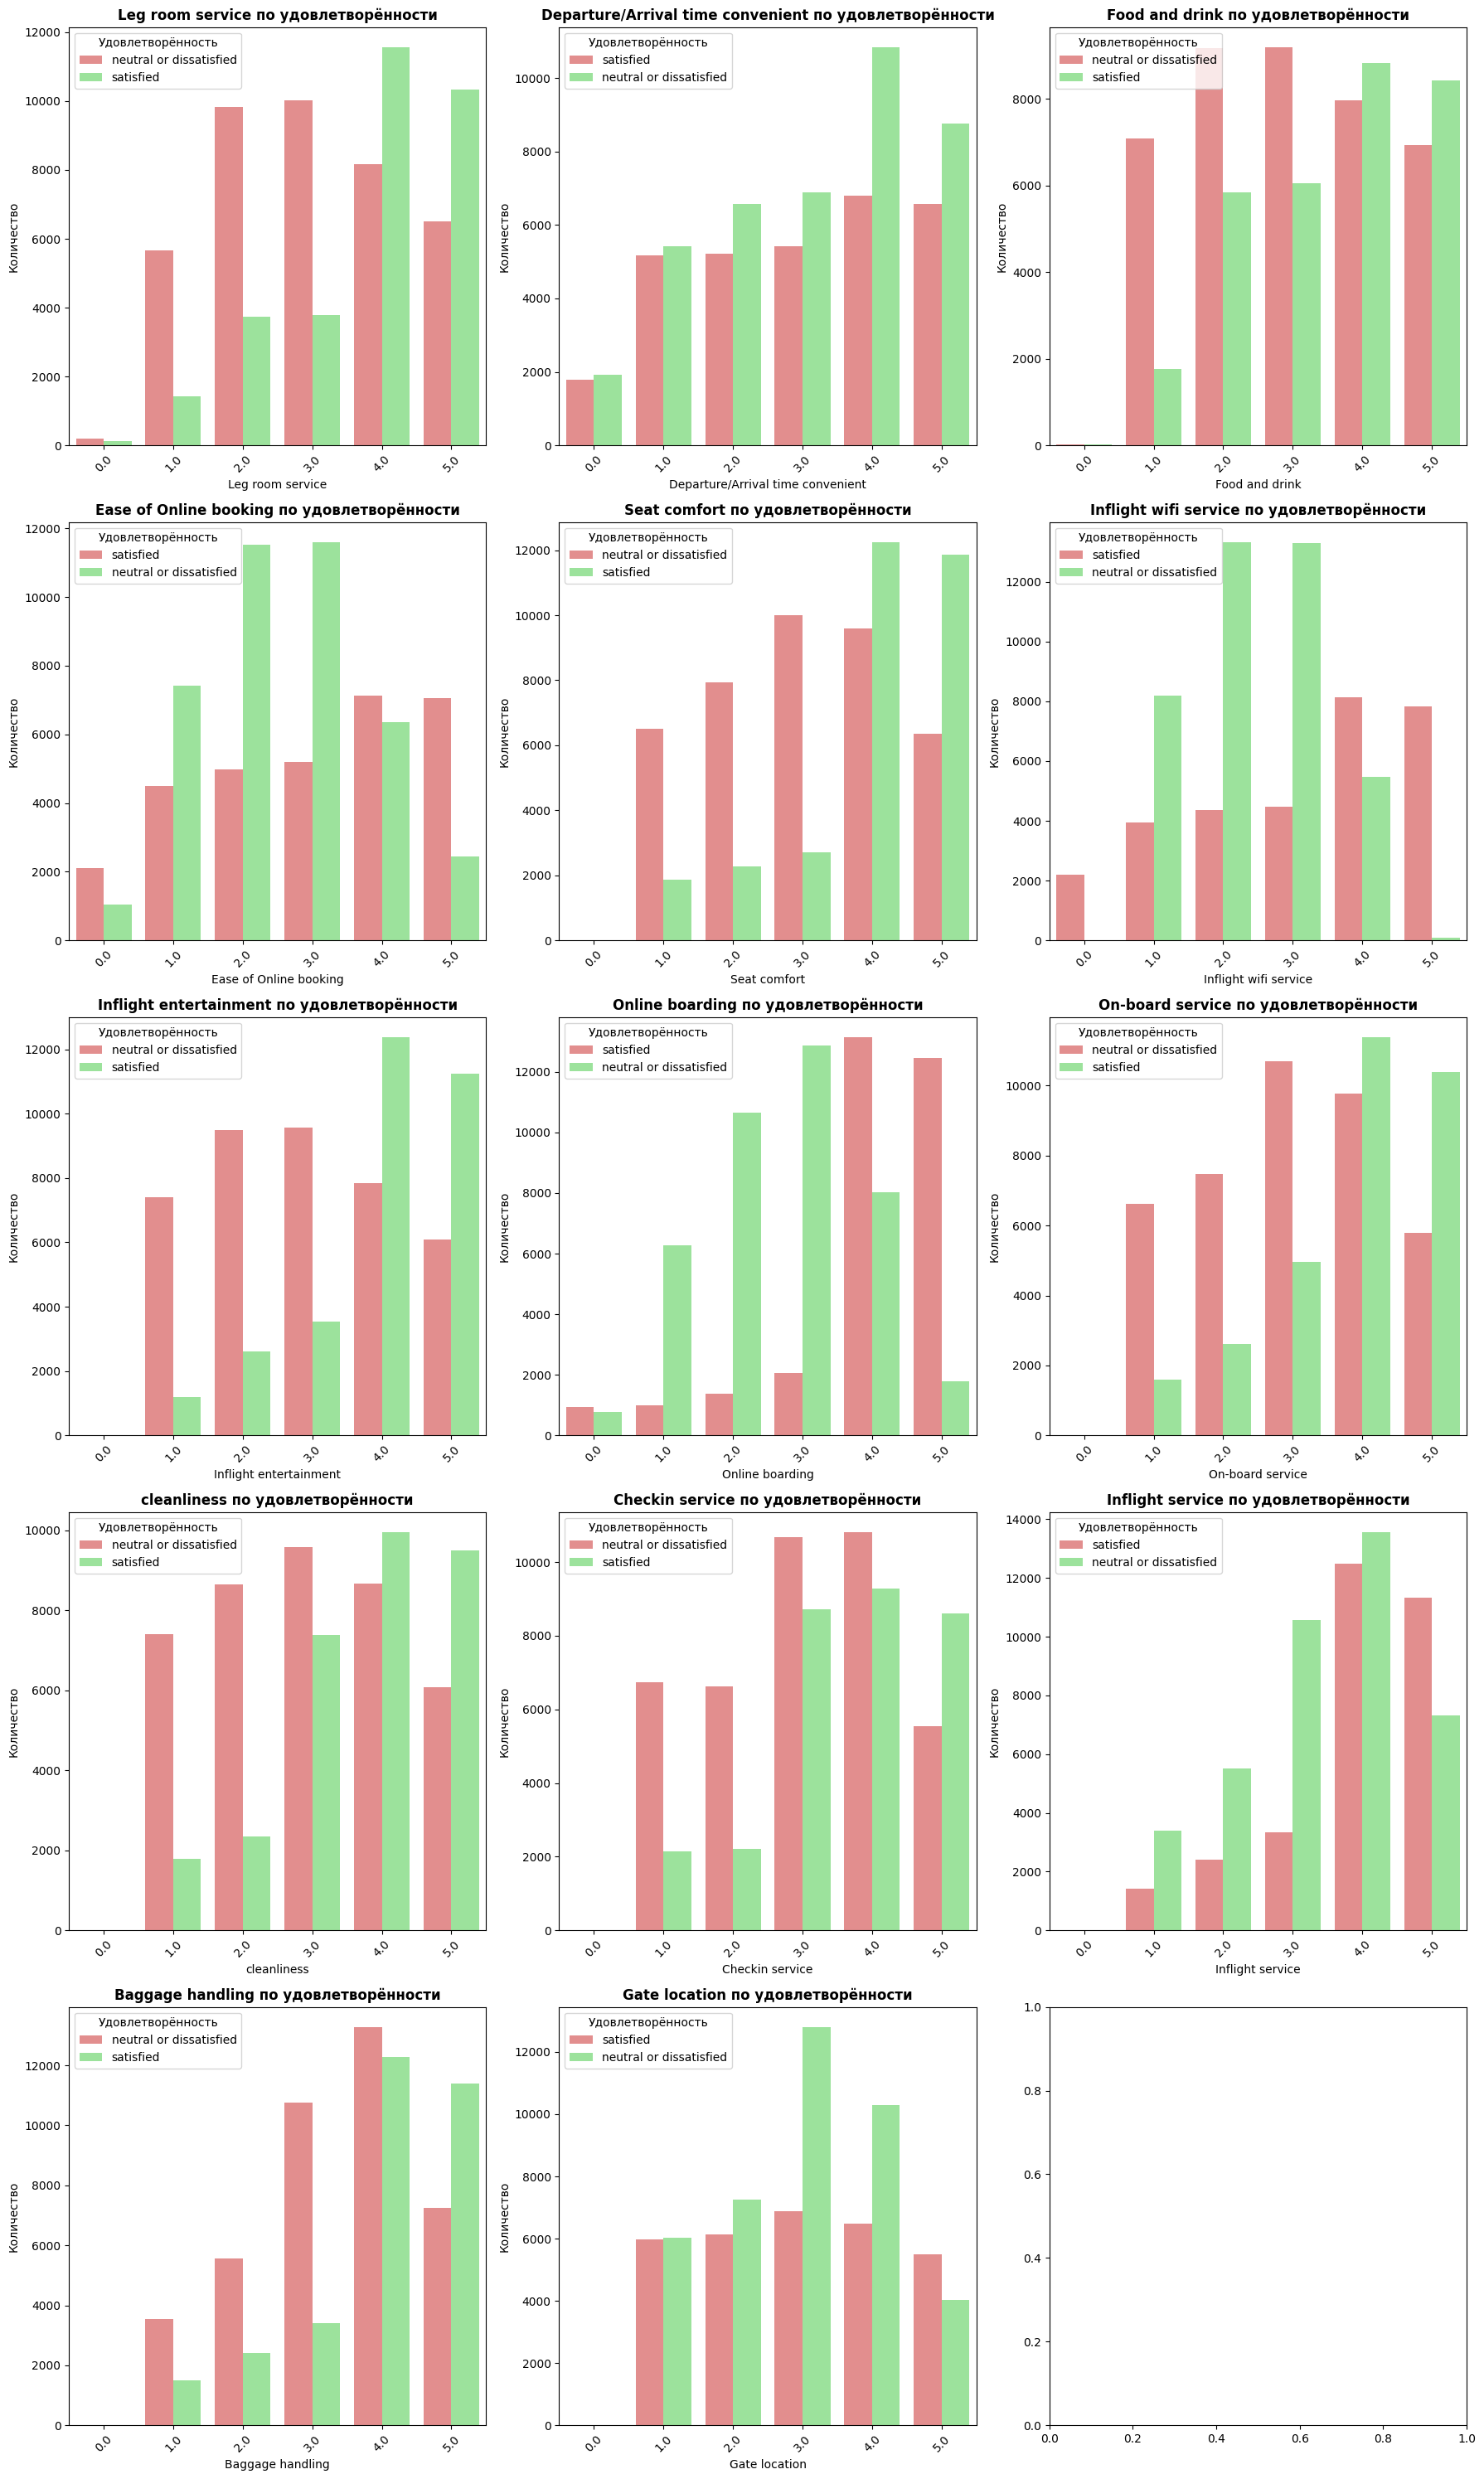

In [38]:
plot_ordinal(ordinal_cols, X_train, y_train)

/tmp/ipython-input-2650843489.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pd.concat([X_train, y_train], axis=1), x=y_train,


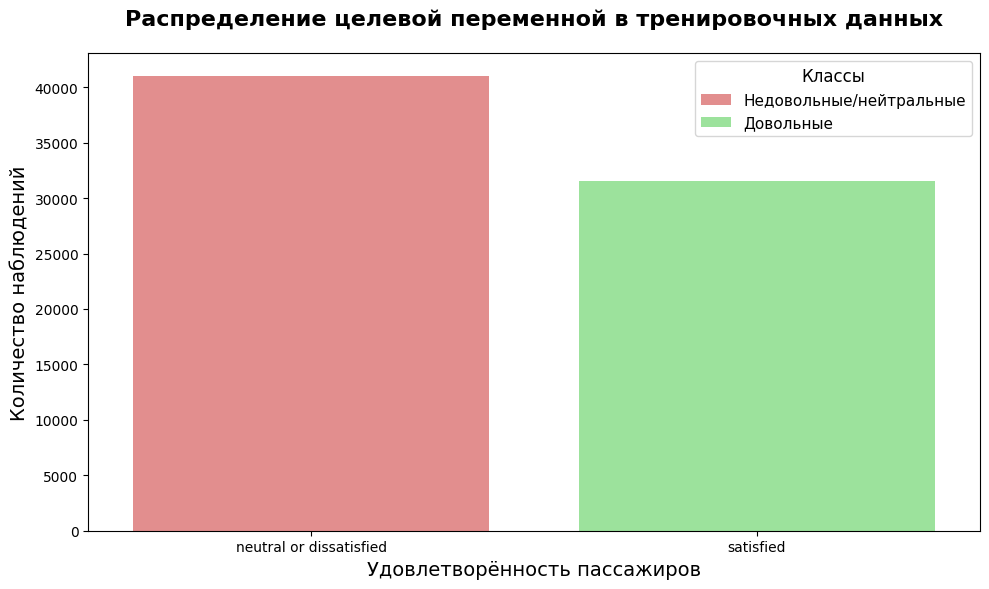

In [39]:
plt.figure(figsize=(10, 6))
sns.countplot(data=pd.concat([X_train, y_train], axis=1), x=y_train,
              palette=['lightcoral', 'lightgreen'])
plt.title('Распределение целевой переменной в тренировочных данных',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Удовлетворённость пассажиров', fontsize=14)
plt.ylabel('Количество наблюдений', fontsize=14)
plt.legend(['Недовольные/нейтральные', 'Довольные'], title='Классы',
           title_fontsize=12, fontsize=11)
plt.tight_layout()
plt.show()

### **Задание 8 (0.2 балла)**

Сделайте выводы по построенным графикам.

Не забудьте упомянуть:
* какие признаки распределены неравномерно
* сбалансированы ли классы
* какие распределения имеют континуальные признаки

Выводы:

1. Классы несбалансированы, но дисбаланс не критический. Тем не менее, преобладает класс недовольных/нейтральных пассажиров.
2. Распределения континуальных признаков:
 * Возраст:
   * Имеет распределение, близкое к нормальному, но с небольшой "просадкой" в середине и несколькими пиками.
   * Охватывает диапазон от детей до пожилых людей, основная масса — от 20 до 60 лет.
 * Дальность полета:
   * Имеет скошенное вправо распределение. Короткие перелеты встречаются чаще, чем длинные.
   * Присутствует длинный хвост в сторону больших дистанций.
 * Задержки (Departure Delay / Arrival Delay):
   * Имеют экстремально скошенное вправо распределение.
   * Подавляющее большинство значений находится около нуля, то есть рейсы без задержек.
   * На boxplot видно огромное количество выбросов, уходящих вверх. Это говорит о том, что большинство рейсов вылетает вовремя, но если задержка случается, она может быть очень длительной.
3. Неравномерно распределенные признаки
Анализируя категориальные и порядковые признаки, можно выделить следующие неравномерности:
 * Тип лояльности (Customer Type): Признак распределен очень неравномерно. Лояльных (Loyal Customer) пассажиров значительно больше, чем нелояльных.
 * Класс обслуживания (Class): Класс Eco Plus представлен очень малым количеством наблюдений по сравнению с Business и Eco.
 * Тип поездки (Type of Travel): Деловых поездок (Business travel) заметно больше, чем личных (Personal Travel).

4. Распределение признаков удовлетворенности:
 * Type of Travel: Четко видно, что люди в деловых поездках (Business travel) чаще довольны (зеленый столбец выше красного), в то время как в личных поездках (Personal Travel) подавляющее большинство недовольно.
 * Class: В Бизнес-классе доля довольных пассажиров значительно превышает долю недовольных. В Экономе ситуация обратная.
 * Оценки сервиса:
   * Для таких признаков, как Inflight entertainment (развлечения), Seat comfort (удобство кресла), Leg room service, наблюдается сильная корреляция с целевой переменной: оценки 4 и 5 в основном ставят довольные пассажиры, а 1, 2, 3 — недовольные.
   * Признак Gate location (расположение выхода), судя по графику, не имеет такого явного влияния на разделение классов (столбцы более перемешаны).


### **Бонус (0.1 балла)**
По графикам (каким, решите сами) оцените, похожи ли оказались распределения признаков при разбиении на трейн, валидацию и тест.

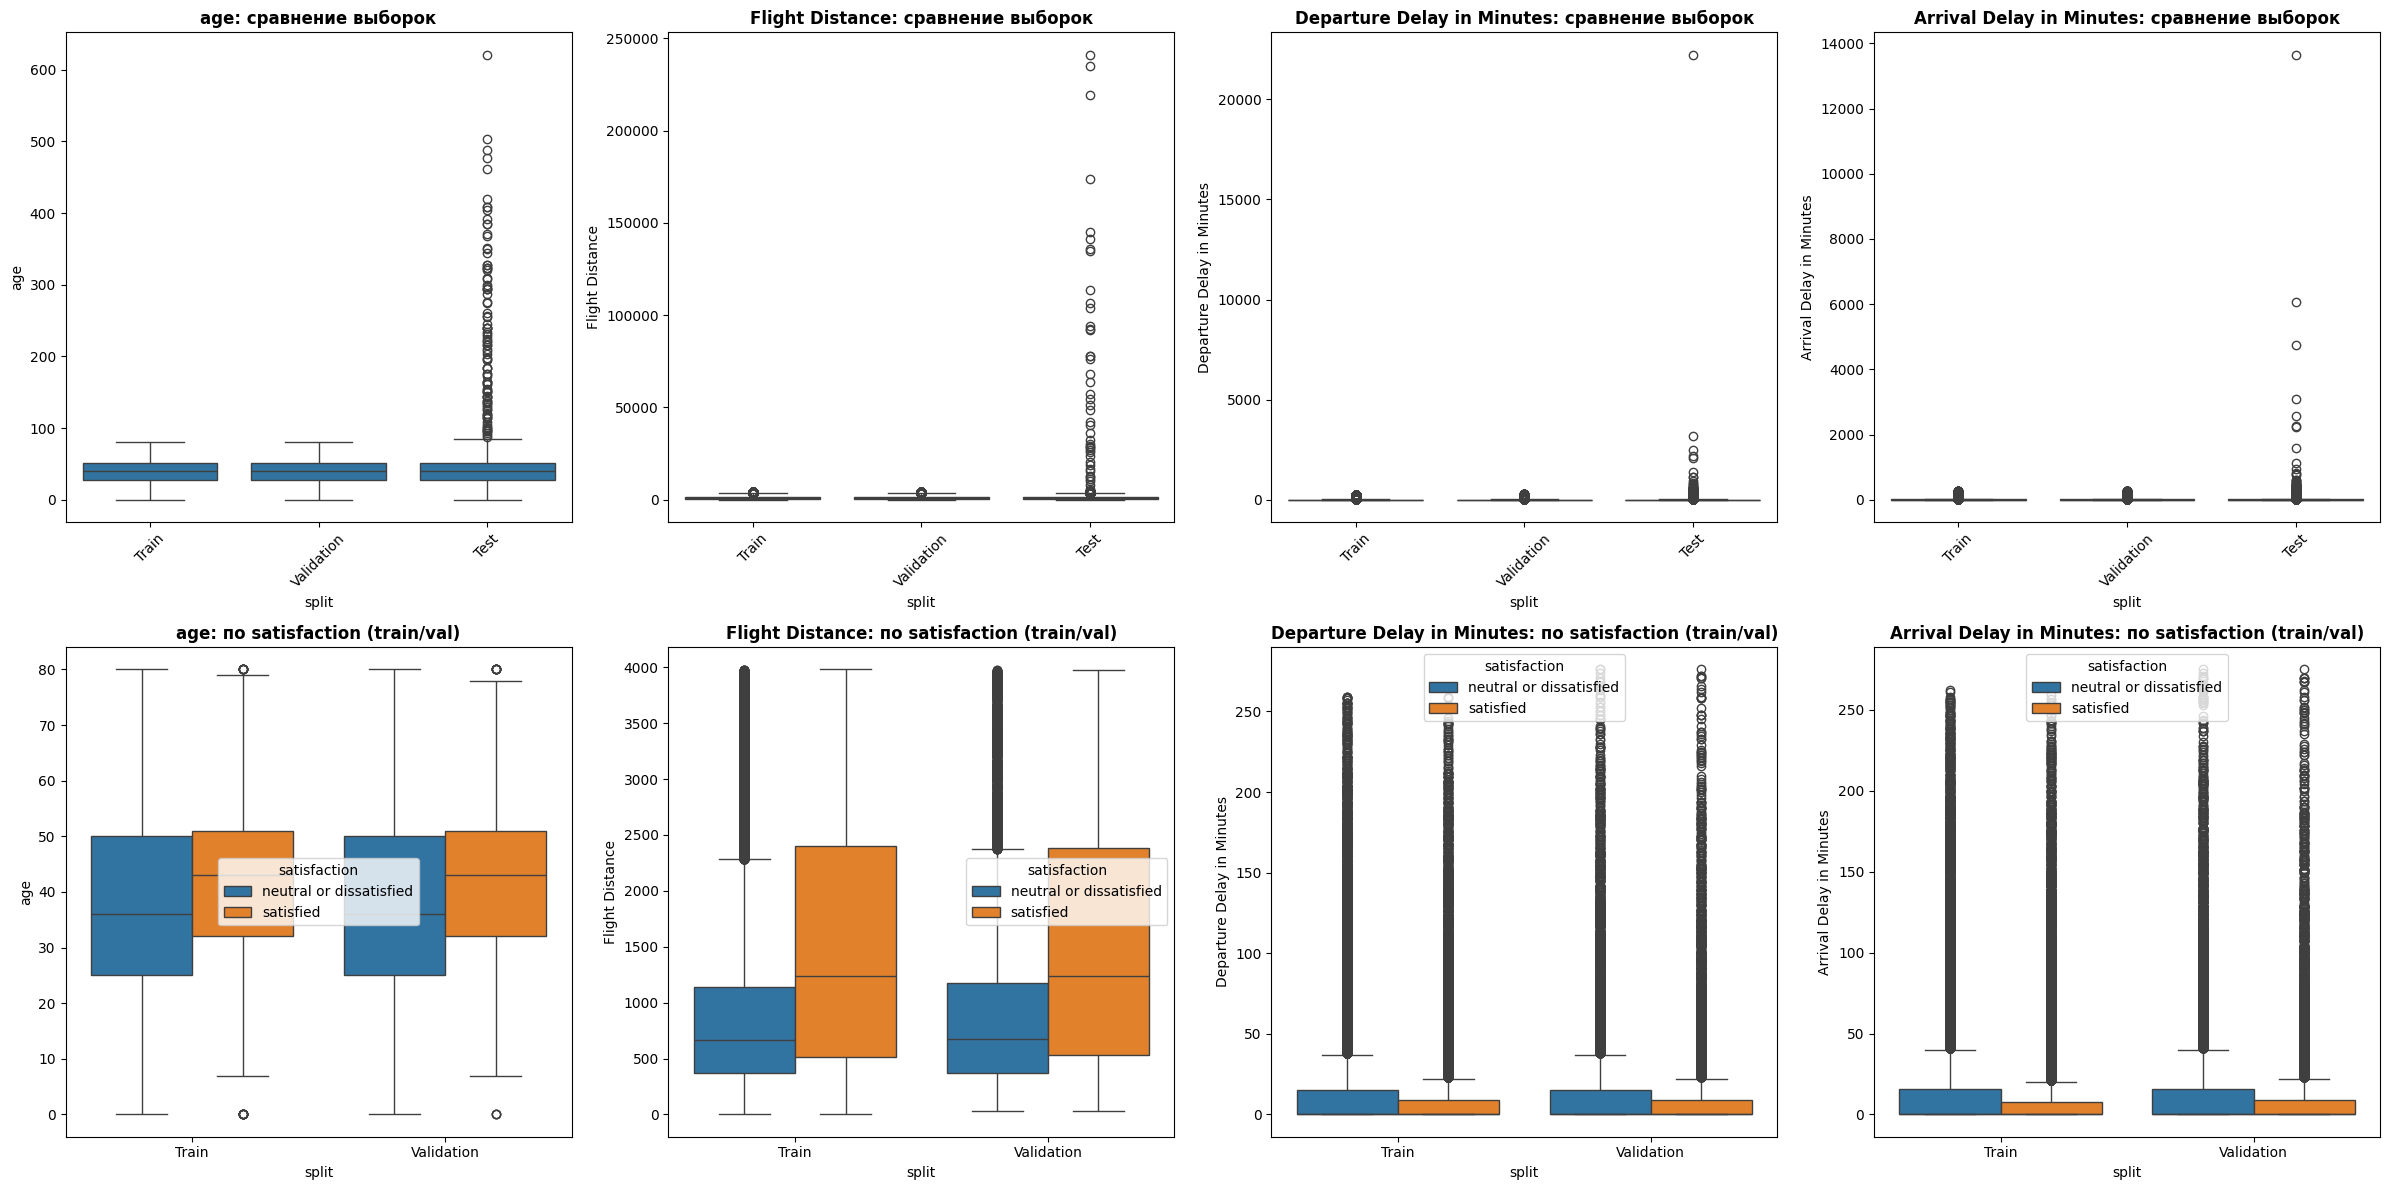

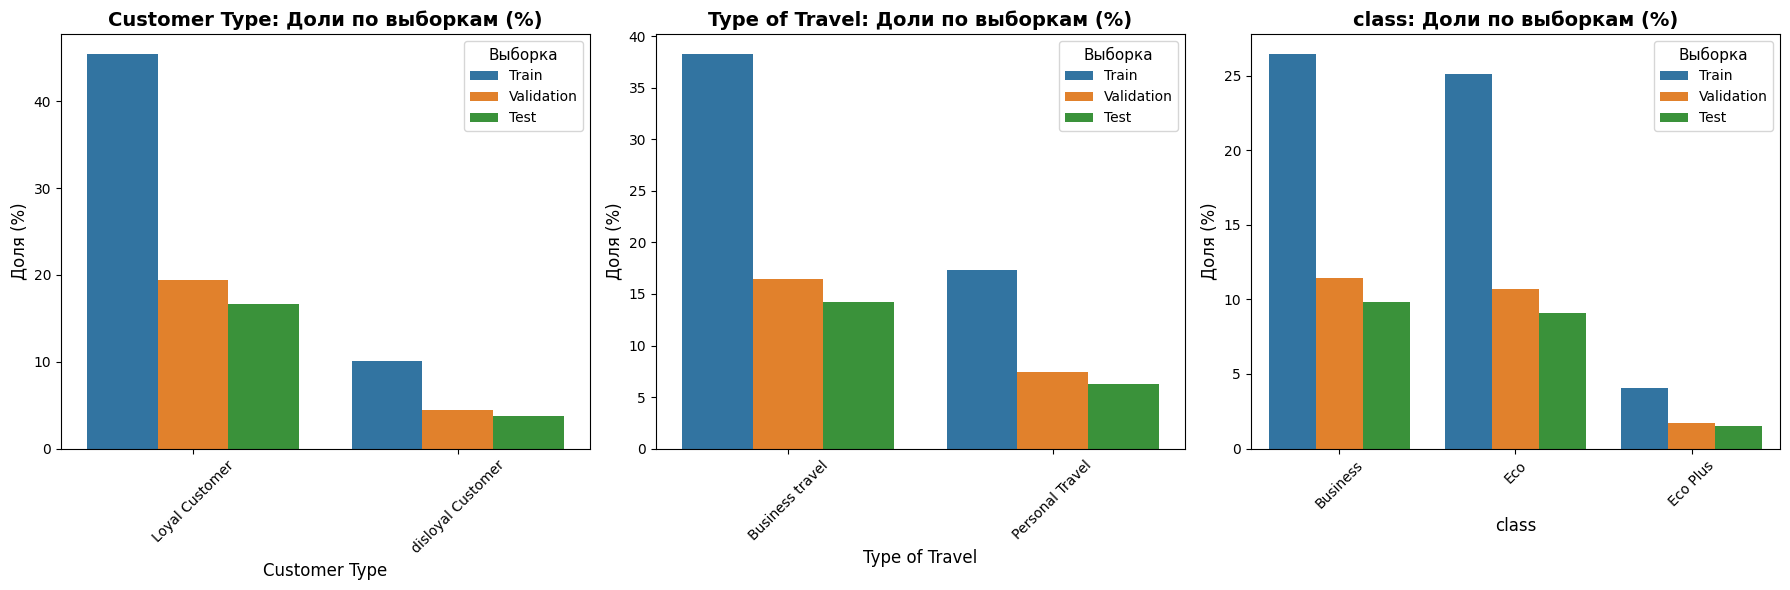

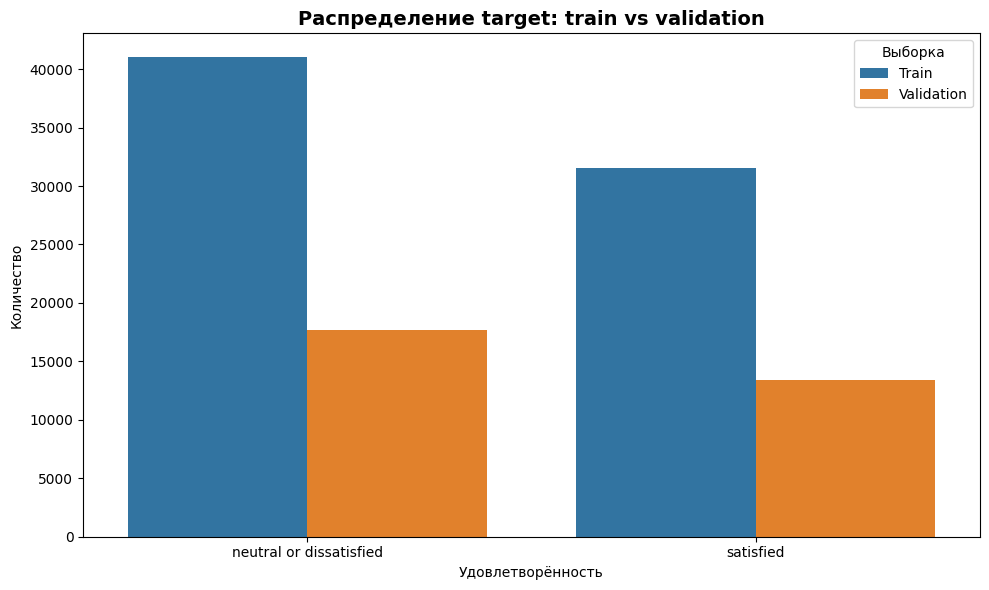

In [27]:
from scipy.stats import ks_2samp

def compare_distributions(X_train, X_val, df_test, y_train=None, y_val=None):
    """Сравнение распределений train/val/test """

    train_df = X_train.copy()
    train_df['split'] = 'Train'
    if y_train is not None:
        train_df['satisfaction'] = y_train

    val_df = X_val.copy()
    val_df['split'] = 'Validation'
    if y_val is not None:
        val_df['satisfaction'] = y_val

    test_df = df_test.copy()
    test_df['split'] = 'Test'

    combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

    continuous_cols = ['age', 'Flight Distance', 'Departure Delay in Minutes',
                      'Arrival Delay in Minutes']
    categorical_cols = ['Customer Type', 'Type of Travel', 'class']

    # Boxplot для continuous
    n_cont_cols = len(continuous_cols)
    fig, axes = plt.subplots(2, n_cont_cols, figsize=(6*n_cont_cols, 12))

    for i, col in enumerate(continuous_cols):
        if col in combined_df.columns:
            sns.boxplot(data=combined_df, x='split', y=col, ax=axes[0, i])
            axes[0, i].set_title(f'{col}: сравнение выборок', fontweight='bold')
            axes[0, i].tick_params(axis='x', rotation=45)

            if 'satisfaction' in combined_df.columns:
                mask = combined_df['split'].isin(['Train', 'Validation'])
                sns.boxplot(data=combined_df[mask], x='split', y=col,
                          hue='satisfaction', ax=axes[1, i])
                axes[1, i].set_title(f'{col}: по satisfaction (train/val)', fontweight='bold')
            else:
                axes[1, i].text(0.5, 0.5, 'Нет таргета', ha='center', va='center',
                              transform=axes[1, i].transAxes)
                axes[1, i].set_title(f'{col}: нет таргета', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Countplot
    fig, axes = plt.subplots(1, len(categorical_cols), figsize=(6*len(categorical_cols), 6))
    if len(categorical_cols) == 1:
        axes = [axes]

    for i, col in enumerate(categorical_cols):
        sns.countplot(data=combined_df, x=col, hue='split',
                     ax=axes[i], stat='percent')
        axes[i].set_title(f'{col}: Доли по выборкам (%)', fontweight='bold', fontsize=14)
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('Доля (%)', fontsize=12)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(title='Выборка', title_fontsize=11)

    plt.tight_layout()
    plt.show()

    # Target только для train/val
    if y_train is not None and y_val is not None:
        target_df = pd.DataFrame({
            'satisfaction': pd.concat([y_train, y_val]),
            'split': ['Train']*len(y_train) + ['Validation']*len(y_val)
        })
        plt.figure(figsize=(10, 6))
        sns.countplot(data=target_df, x='satisfaction', hue='split')
        plt.title('Распределение target: train vs validation', fontweight='bold', fontsize=14)
        plt.xlabel('Удовлетворённость')
        plt.ylabel('Количество')
        plt.legend(title='Выборка')
        plt.tight_layout()
        plt.show()


compare_distributions(X_train, X_val, df_test, y_train, y_val)


Вывод:
Данные трейна и валидации очень схожи. Тестовые данные отличаются (более грязные) из-за выбросов.

### **Задание 9 (0.25 балла)**

- Замените признаки "Departure Delay in Minutes" и "Arrival Delay in Minutes" на их логарифмы.
- Заново постройте графики континуальных признаков и сделайте вывод по преобразованию

Некоторые признаки полезно рассматривать в логарифмической шкале. Зачем? Она помогает анализировать большие диапазоны изменений (посмотрите на график логарифма).


In [28]:
import numpy as np

for dataset in [X_train, X_val]:
    dataset['log_Departure_Delay'] = np.log1p(
        pd.to_numeric(dataset['Departure Delay in Minutes'], errors='coerce')
    )
    dataset['log_Arrival_Delay'] = np.log1p(
        pd.to_numeric(dataset['Arrival Delay in Minutes'], errors='coerce')
    )

continuous_cols_log = ['log_Departure_Delay', 'log_Arrival_Delay']


Графики до логарифма:


/tmp/ipython-input-3203596686.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=y, y=col, ax=axes[i, 1],
/tmp/ipython-input-3203596686.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=y, y=col, ax=axes[i, 1],


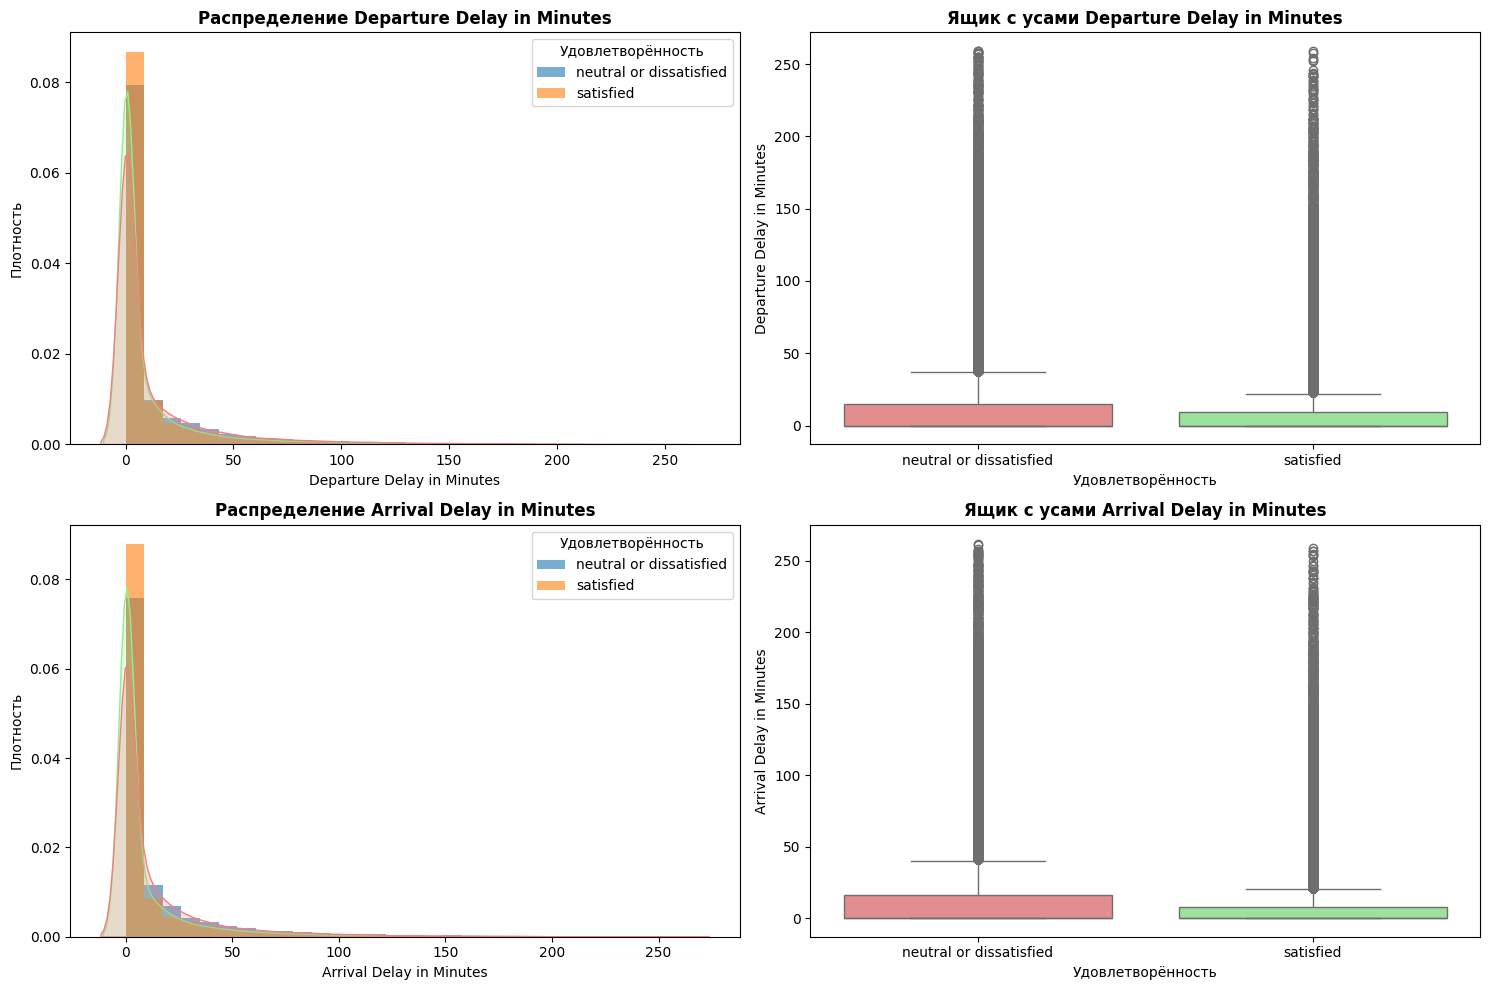

Графики после логарифмирования:


/tmp/ipython-input-3203596686.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=y, y=col, ax=axes[i, 1],
/tmp/ipython-input-3203596686.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=y, y=col, ax=axes[i, 1],


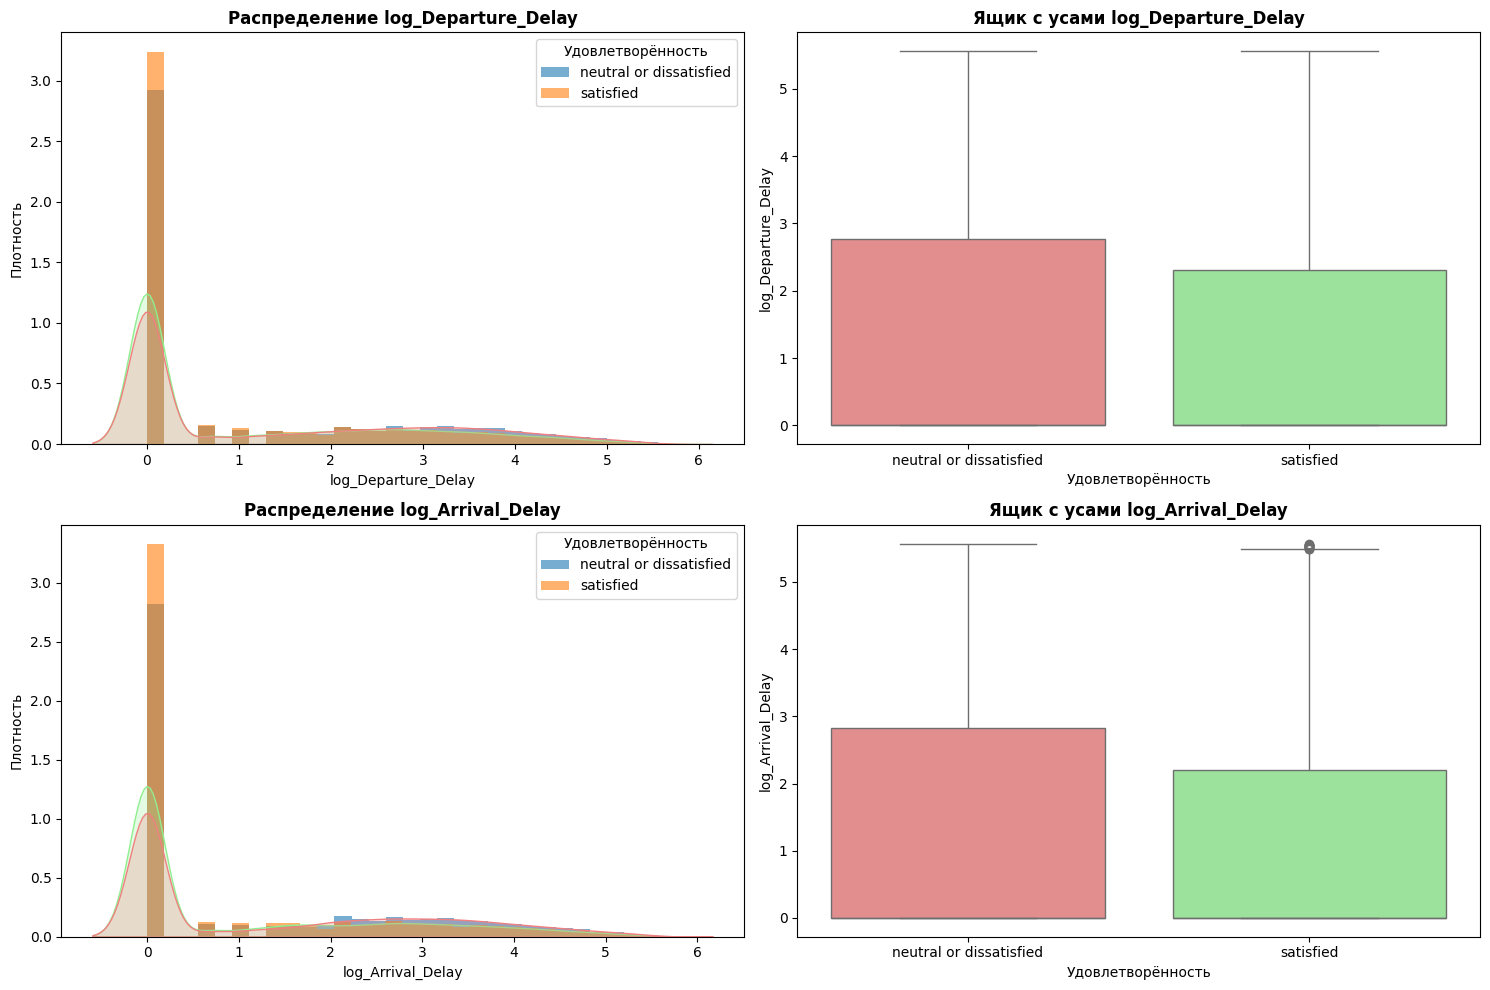

In [29]:
print("Графики до логарифма:")
plot_continuous(['Departure Delay in Minutes', 'Arrival Delay in Minutes'],
                X_train, y_train)

print("Графики после логарифмирования:")
plot_continuous(continuous_cols_log, X_train, y_train)

Вывод:

Графики стали более читаемы, так как устранилась сильная ассиметрия (логаримф сжал большие значения и растянул маленькие) - граф стал больше похож на нормальное распределение. На boxplot исчезли точки (выбросы).

По сути данное преобразование приводит к нормальному распределению и помогает модели лучше находить закономерности, а также делает ее более устойчивой.

### **Задание 10 (0.25 балла)**

Выше вы рассмотрели `boxplot` и графики распределений. Но иногда полезным оказывается `scatterplot, (pairplot)` в seabron. Проверьте, что покажет этот график в нашей задаче.

- Отобразите попарное распределение континуальных (по договоренности) признаков. Покрасьте точки на pairplot'е в соответствии с их классом.

**Примечание:**
Наблюдений много, так что отрисовка графика вполне может занять несколько минут

<Figure size 1200x1000 with 0 Axes>

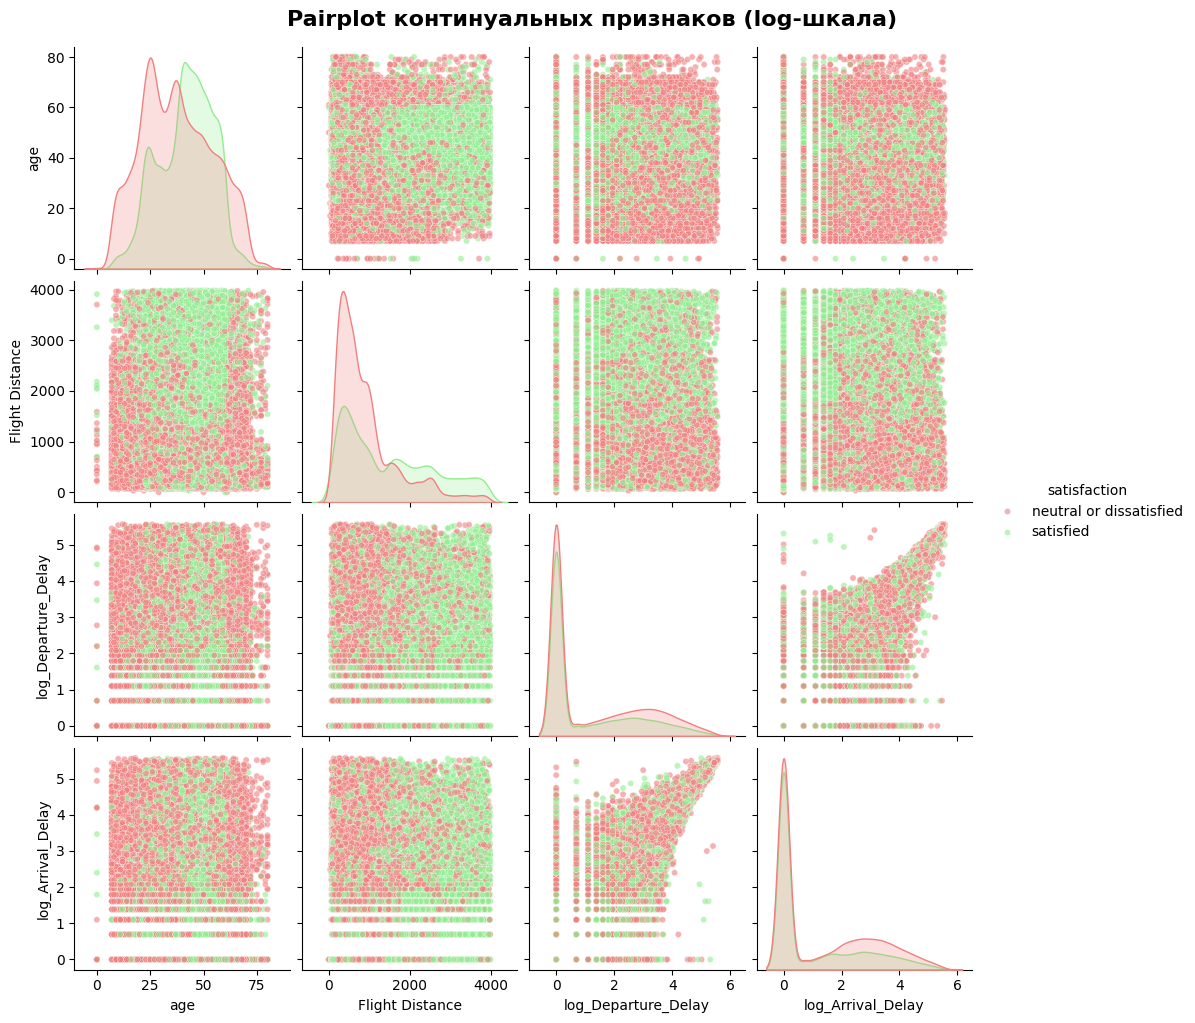

In [30]:
continuous_cols_log = ['age', 'Flight Distance', 'log_Departure_Delay', 'log_Arrival_Delay']
train_data = X_train[continuous_cols_log].copy()
train_data['satisfaction'] = y_train

plt.figure(figsize=(12, 10))
sns.pairplot(train_data, hue='satisfaction', diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 20}, diag_kws={'fill': True},
             palette=['lightcoral', 'lightgreen'])
plt.suptitle('Pairplot континуальных признаков (log-шкала)',
             fontsize=16, fontweight='bold', y=1.02)
plt.show()



# **Часть 2. Decision Tree (3 балла)**

### **Задание 11 (0.4 балла)**

Предобработайте данные для алгоритма.
- Закодируйте таргет таким образом, чтоб 'satisfied' перешел в 1, а остальные значения в 0;
- Закодируйте категориальные признаки методом OHE;

In [31]:
def encode_target(y):
    """Бинарное кодирование таргета"""
    y_encoded = (y == 'satisfied').astype(int)
    return y_encoded

y_train_bin = encode_target(y_train)
y_val_bin = encode_target(y_val)

print("Распределение таргета после бинарного кодирования:")
print("Train:", np.bincount(y_train_bin))
print("Val:", np.bincount(y_val_bin))


Распределение таргета после бинарного кодирования:
Train: [41010 31540]
Val: [17722 13372]


In [32]:
categorical_cols= ['gender', 'Customer Type', 'Type of Travel', 'class']

ohe = OneHotEncoder(sparse_output=False, drop='first')

ohe.fit(X_train[categorical_cols])

X_train_ohe = pd.concat([
    X_train.drop(columns=categorical_cols),
    pd.DataFrame(
        ohe.transform(X_train[categorical_cols]),
        columns=ohe.get_feature_names_out(categorical_cols),
        index=X_train.index
    )
], axis=1)

X_val_ohe = pd.concat([
    X_val.drop(columns=categorical_cols),
    pd.DataFrame(
        ohe.transform(X_val[categorical_cols]),
        columns=ohe.get_feature_names_out(categorical_cols),
        index=X_val.index
    )
], axis=1)

print("\nРазмерности после OHE:")
print(f"X_train_ohe: {X_train_ohe.shape}")
print(f"X_val_ohe: {X_val_ohe.shape}")

print("\nOHE столбцы:")
print(ohe.get_feature_names_out(categorical_cols))


Размерности после OHE:
X_train_ohe: (70470, 28)
X_val_ohe: (30217, 28)

OHE столбцы:
['gender_Male' 'Customer Type_disloyal Customer' 'Customer Type_nan'
 'Type of Travel_Personal Travel' 'Type of Travel_nan' 'class_Eco'
 'class_Eco Plus' 'class_nan']


In [36]:
print("текущие размеры:")
print(f"X_train_ohe: {X_train_ohe.shape}")
print(f"y_train_bin: {len(y_train_bin)}")
print(f"X_val_ohe: {X_val_ohe.shape}")
print(f"y_val_bin: {len(y_val_bin)}")

X_train_ohe = X_train_ohe.iloc[:min_train].copy()
y_train_bin = y_train_bin[:min_train]
X_val_ohe = X_val_ohe.iloc[:min_val].copy()
y_val_bin = y_val_bin[:min_val]


print("после синхронизации:")
print(f"X_train_ohe: {X_train_ohe.shape}, y_train_bin: {len(y_train_bin)}")
print(f"X_val_ohe: {X_val_ohe.shape}, y_val_bin: {len(y_val_bin)}")


ТЕКУЩИЕ размеры:
X_train_ohe: (70470, 28)
y_train_bin: 70470
X_val_ohe: (30217, 28)
y_val_bin: 30217

ПОСЛЕ синхронизации:
X_train_ohe: (70470, 28), y_train_bin: 70470
X_val_ohe: (30217, 28), y_val_bin: 30217


### **Задание 12. (0.1 балла)**

- Обучите дерево решений с параметрами по умолчанию на имеющихся данных.
- Выведите `accuracy_score` для валидационной подвыборки

**Примечание**:

Здесь и далее, где вас просят что-нибудь обучить, выводите **везде** `accuracy_score` для валидационной подвыборки.

In [34]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_ohe, y_train_bin)

y_val_pred = dt.predict(X_val_ohe)

val_accuracy = accuracy_score(y_val_pred, y_val_bin)
print(f"Accuracy на валидационной выборке: {val_accuracy:.4f}")

y_train_pred = dt.predict(X_train_ohe)
train_accuracy = accuracy_score(y_train_pred, y_train_bin)
print(f"Accuracy на тренировочной выборке: {train_accuracy:.4f}")

Accuracy на валидационной выборке: 0.5040
Accuracy на тренировочной выборке: 1.0000


## **Анализ построенной модели**

### **Задание 13. (0.5 балла)**

- Посчитайте bias и variance для построенного дерева. Для этого проще всего вспользоваться функцией `bias_variance_decomp()` из модуля mlxtend. Используйте '0-1_loss'

In [35]:
from mlxtend.evaluate import bias_variance_decomp
error_dt, bias_dt, var_dt = bias_variance_decomp(
    dt,
    X_train_ohe.values,
    y_train_bin.values,
    X_val_ohe.values,
    y_val_bin.values,
    loss='0-1_loss',
    random_seed=42
)

print(f"Error (Expected loss): {error_dt}")
print(f"Bias: {bias_dt}")
print(f"Variance: {var_dt}")

error_dt, bias_dt, var_dt

Error (Expected loss): 0.4925510474236357
Bias: 0.46159446669093557
Variance: 0.4244430287586458


(np.float64(0.4925510474236357),
 np.float64(0.46159446669093557),
 np.float64(0.4244430287586458))

### **Задание 14. (0.2 балла)**

Проанализируйте структурные характеристики дерева.
- Какой глубины получилось дерево?
- Сколько в нем листьев?

In [37]:
depth = dt.tree_.max_depth
print(f"Глубина дерева: {depth}")

n_leaves = dt.tree_.n_leaves
print(f"Количество листьев: {n_leaves}")

n_nodes = dt.tree_.node_count
print(f"Общее количество узлов: {n_nodes}")


Глубина дерева: 51
Количество листьев: 13168
Общее количество узлов: 26335


### **Задание 15. (0.3 балла)**

Проанализируйте важность признаков, вычисляемую в дереве по построению.

- Выведите на экран barplot, демонстрирующий оценки важности признаков.
- Укажите, какие признаки оказались наиболее информативными?

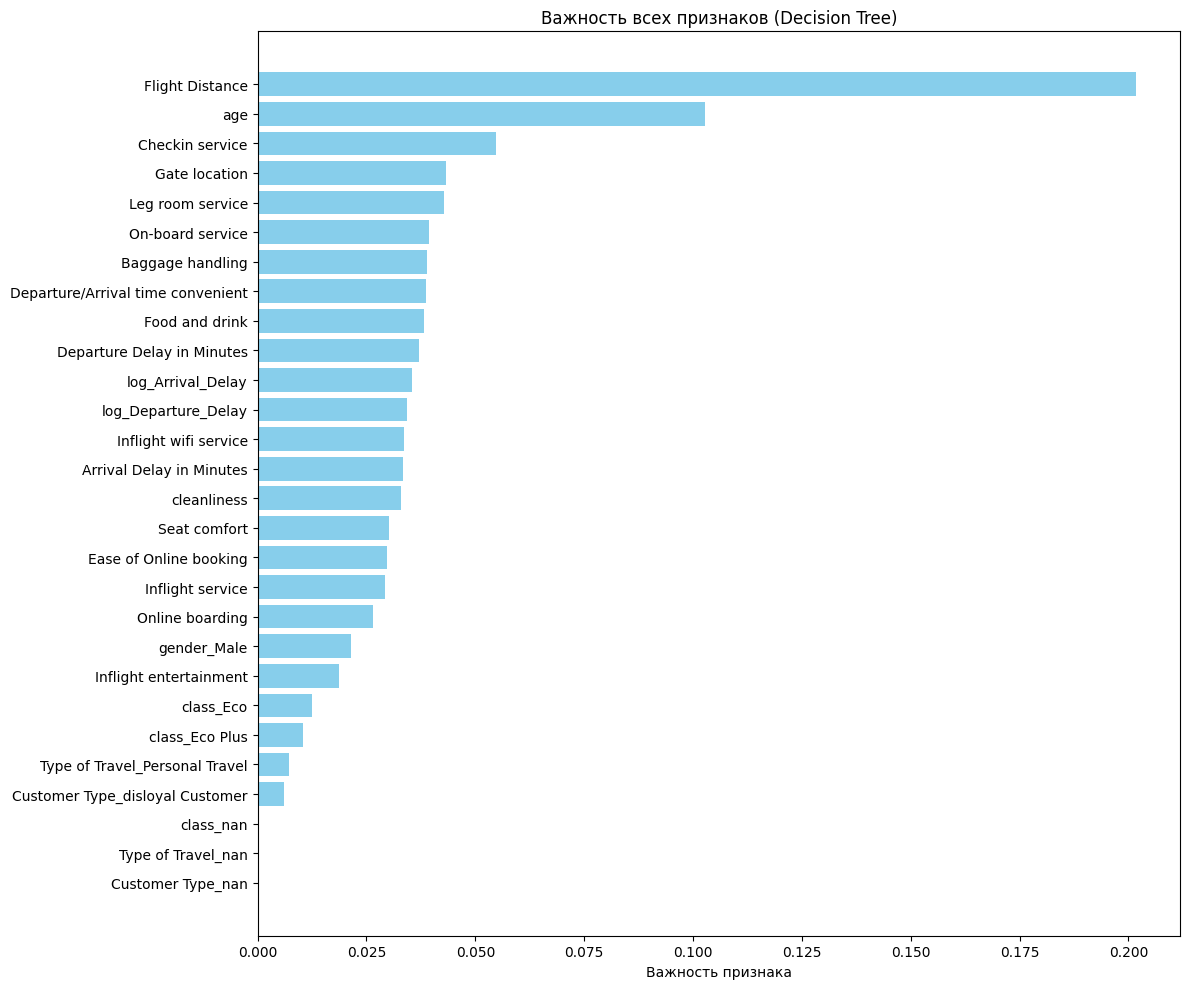

In [38]:
feature_importances = dt.feature_importances_

feature_names = X_train_ohe.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 10))
plt.barh(range(len(importance_df)), importance_df['importance'], color='skyblue')
plt.yticks(range(len(importance_df)), importance_df['feature'])
plt.xlabel('Важность признака')
plt.title('Важность всех признаков (Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Вывод:

Наиболее информативные признаки:

- Flight Distance (19.54%) — Дистанция перелёта сильно влияет на удовлетворённость.
- age (13.46%) — возраст пассажиров также важен
- Checkin service (5.05%) — качество регистрации
- Leg room service (4.43%) — место для ног
- Departure/Arrival time convenient (3.96%) — удобство времени вылета/прилёта

### **Задание 16. (0.1 балла)**

- Постройте дерево глубины 5, используя только 2 наиболее информативных признака для предыдущего построенного дерева.

In [39]:
top_features = ['Flight Distance', 'age']

X_train_top2 = X_train_ohe[top_features]
X_val_top2 = X_val_ohe[top_features]

dt_top2 = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_top2.fit(X_train_top2, y_train_bin)

print(f"Дерево глубины 5 на ТОП-2 признаках:")
print(f"Реальная глубина: {dt_top2.tree_.max_depth}")
print(f"Количество листьев: {dt_top2.tree_.n_leaves}")

y_val_pred_top2 = dt_top2.predict(X_val_top2)
val_accuracy_top2 = accuracy_score(y_val_bin, y_val_pred_top2)
print(f"Accuracy на валидации: {val_accuracy_top2:.4f}")

Дерево глубины 5 на ТОП-2 признаках:
Реальная глубина: 5
Количество листьев: 26
Accuracy на валидации: 0.5703


### **Задание 17. (0.15 балла)**

- С помощью graphviz визуализируйте получившееся новое дерево решений. Почему предикаты в нем не целые, а кратны 1/2?

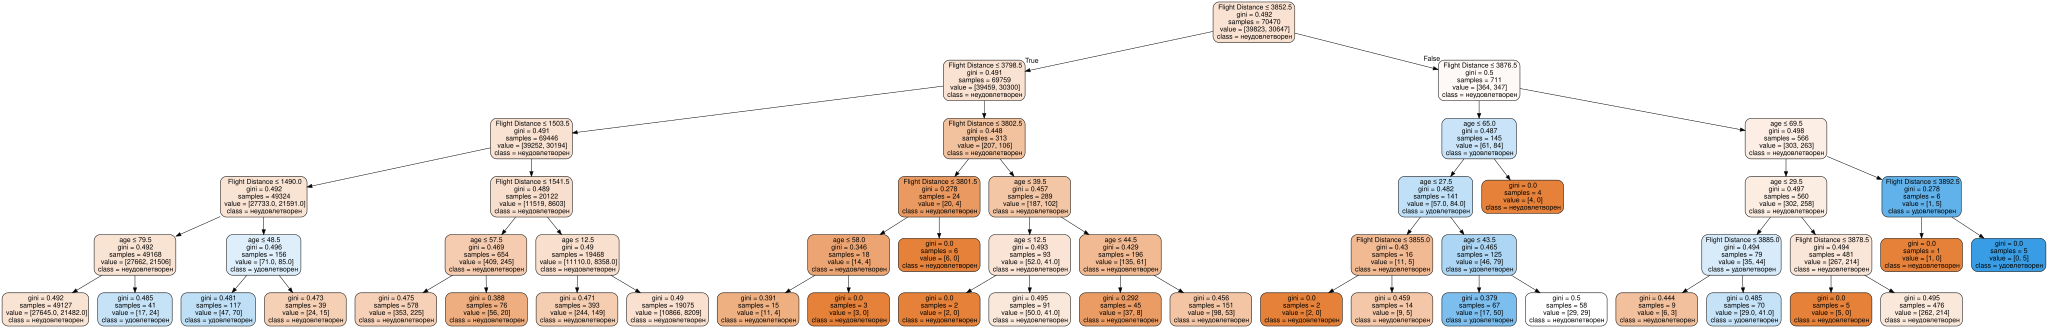

In [40]:
import graphviz

dot_data = export_graphviz(
    dt_top2,
    out_file=None,
    feature_names=top_features,
    class_names=['неудовлетворен', 'удовлетворен'],
    filled=True,
    rounded=True,
    special_characters=True,
    proportion=False
)

graph = graphviz.Source(dot_data)
graph

`Ваш ответ здесь. `

*Гуглить — можно, но помните о культуре цитирования.*

### **Задание 18. (0.25 балла)**

- Теперь отобразите его функцией `plot_tree()` из sklearn.
- Проанализируйте — ссимметричным ли получилось дерево? И хорошо ли это, или нет?

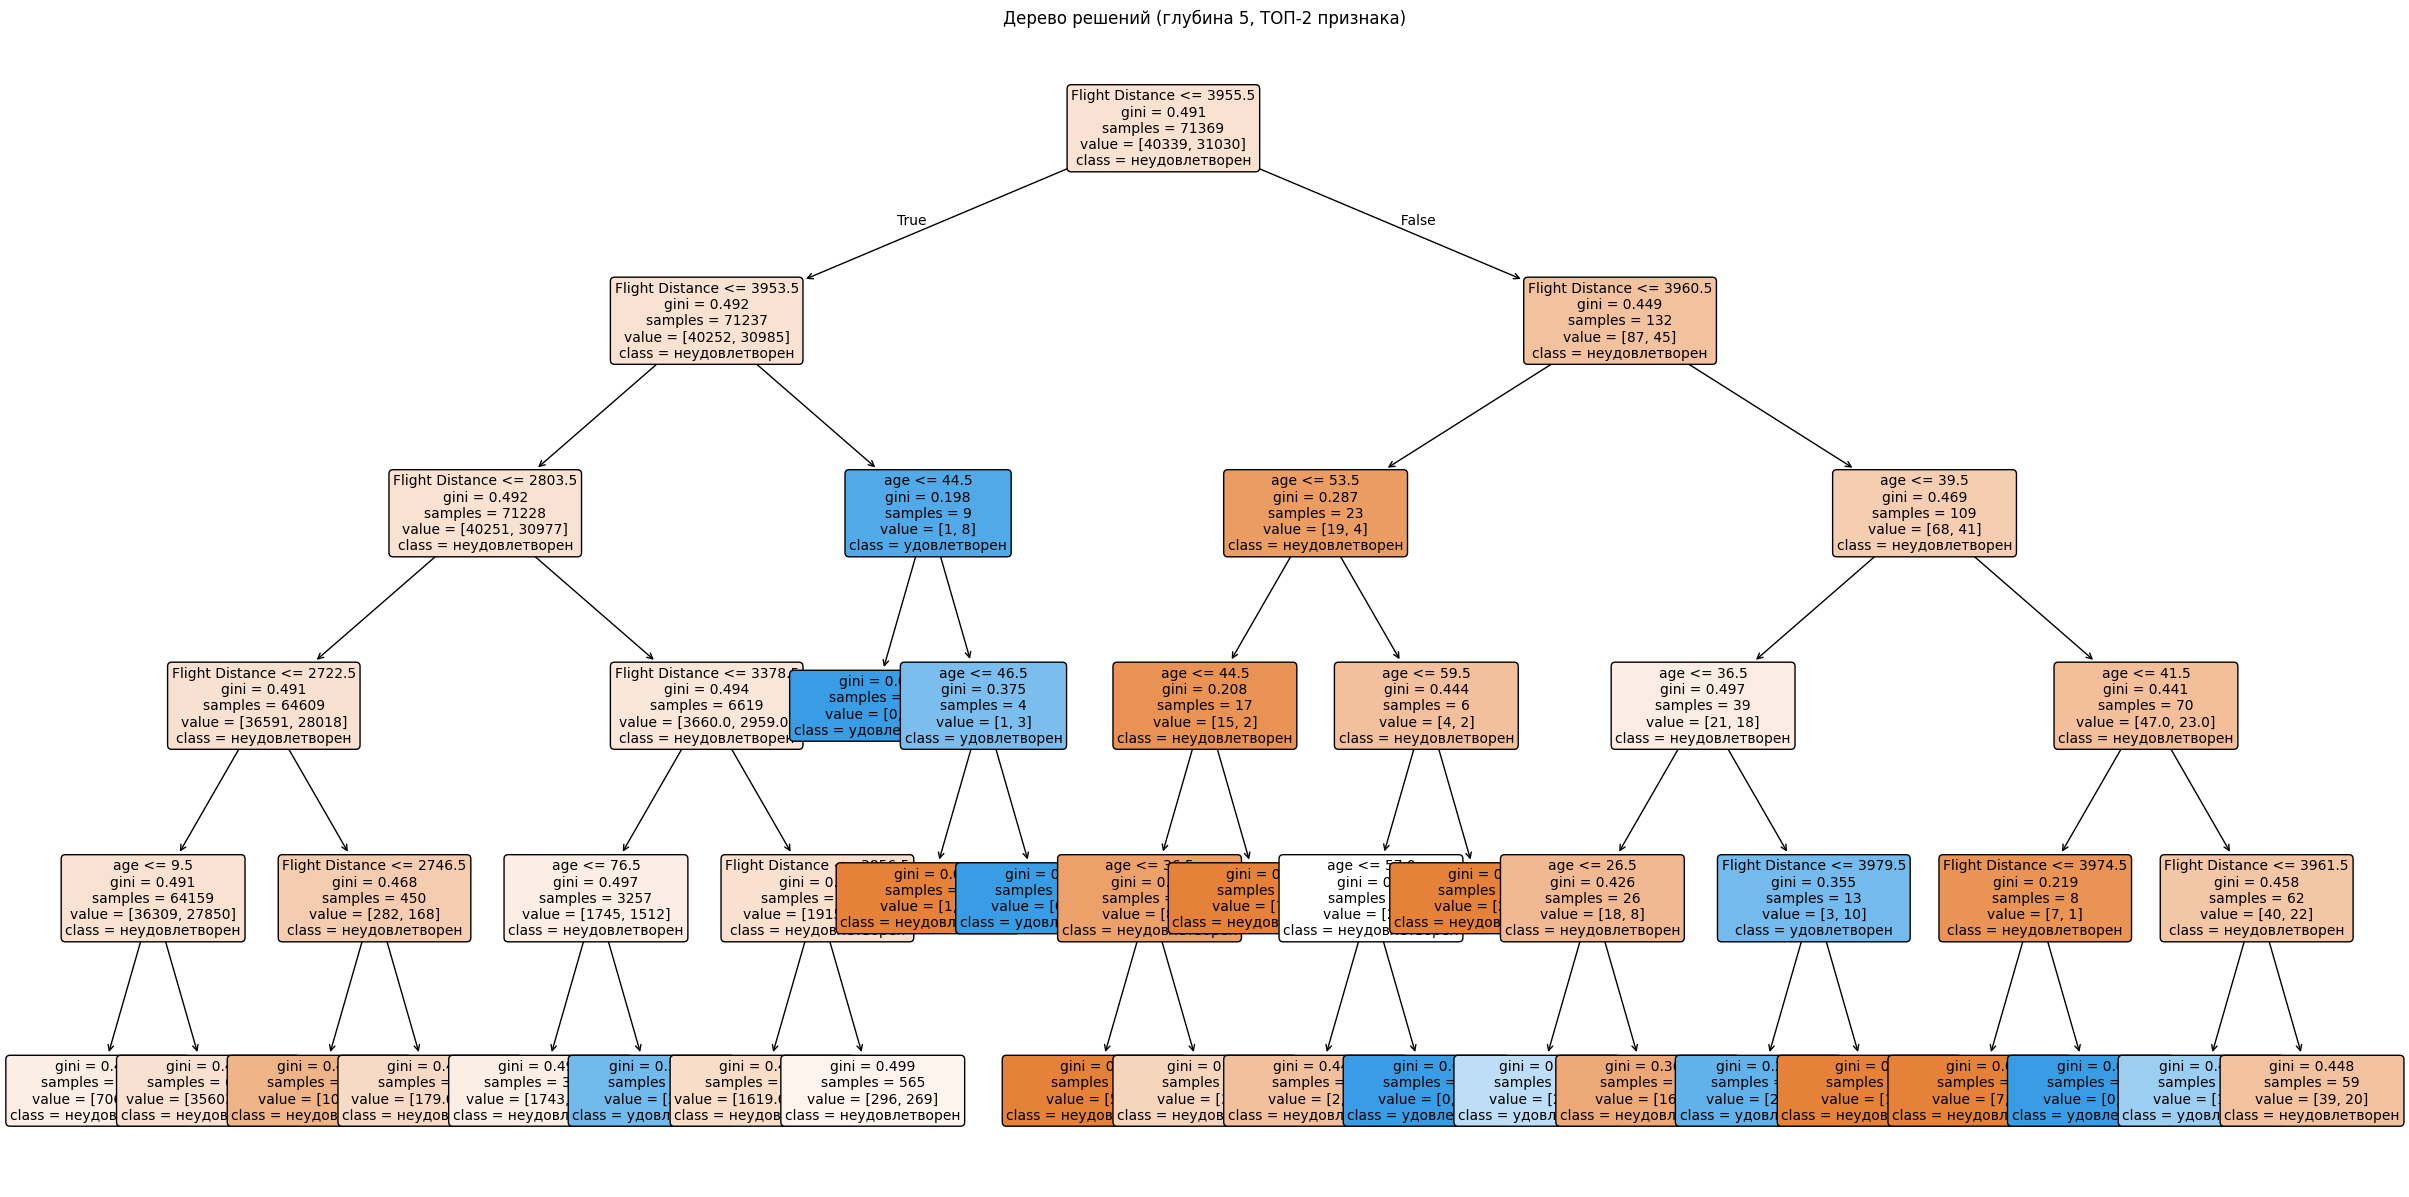

In [70]:
plt.figure(figsize=(30, 15))
plot_tree(
    dt_top2,
    feature_names=top_features,
    class_names=['неудовлетворен', 'удовлетворен'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=5
)
plt.title('Дерево решений (глубина 5, ТОП-2 признака)')
plt.show()


Дерево получилось немного не симметричное (где-то глубина равна 5, где-то 3-4). Но это нормально для реальных данных.

### **Задание 19. (0.5 балла)**

- Используя функцию `plot_decision_regions()` из `mlxtend`, отобразите разделяющую поверхность получившегося дерева. Отметьте на графике только первые 100 объектов обучающей выборки

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


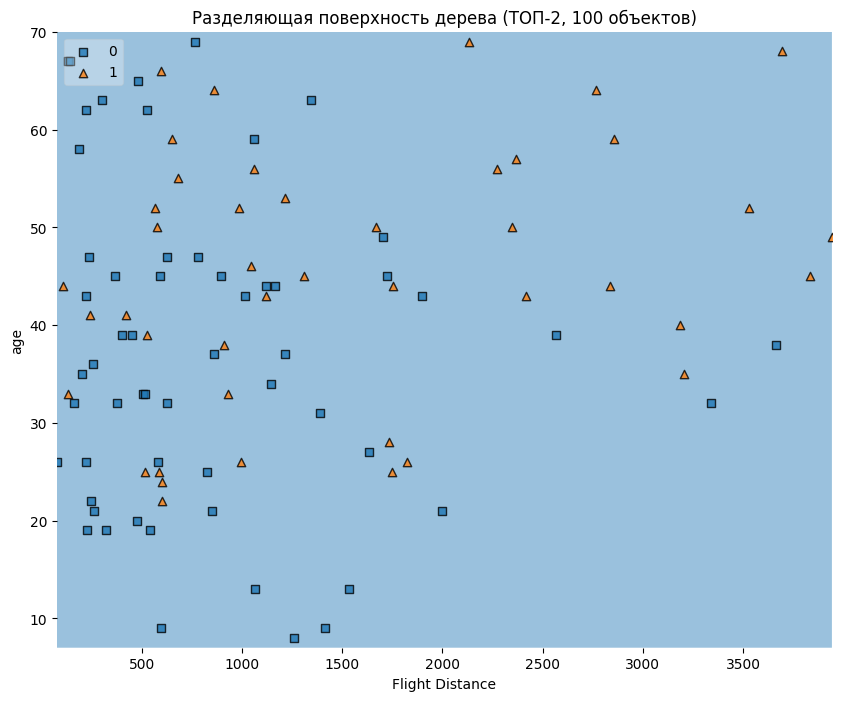

In [72]:
from mlxtend.plotting import plot_decision_regions

X_train_sample = X_train_top2.iloc[:100].astype(np.float64).values
y_train_sample = y_train_bin.iloc[:100].astype(np.int64).values

plt.figure(figsize=(10, 8))
plot_decision_regions(X_train_sample, y_train_sample, clf=dt_top2, legend=2)
plt.xlabel('Flight Distance')
plt.ylabel('age')
plt.title('Разделяющая поверхность дерева (ТОП-2, 100 объектов)')
plt.show()



### **Деревья решений. Теоретическая вставка**

Из лекций вам должно быть известно, что деревья решений неустойчивы даже к небольшим изменениям в обучающей выборке. Попробуем показать это!

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local

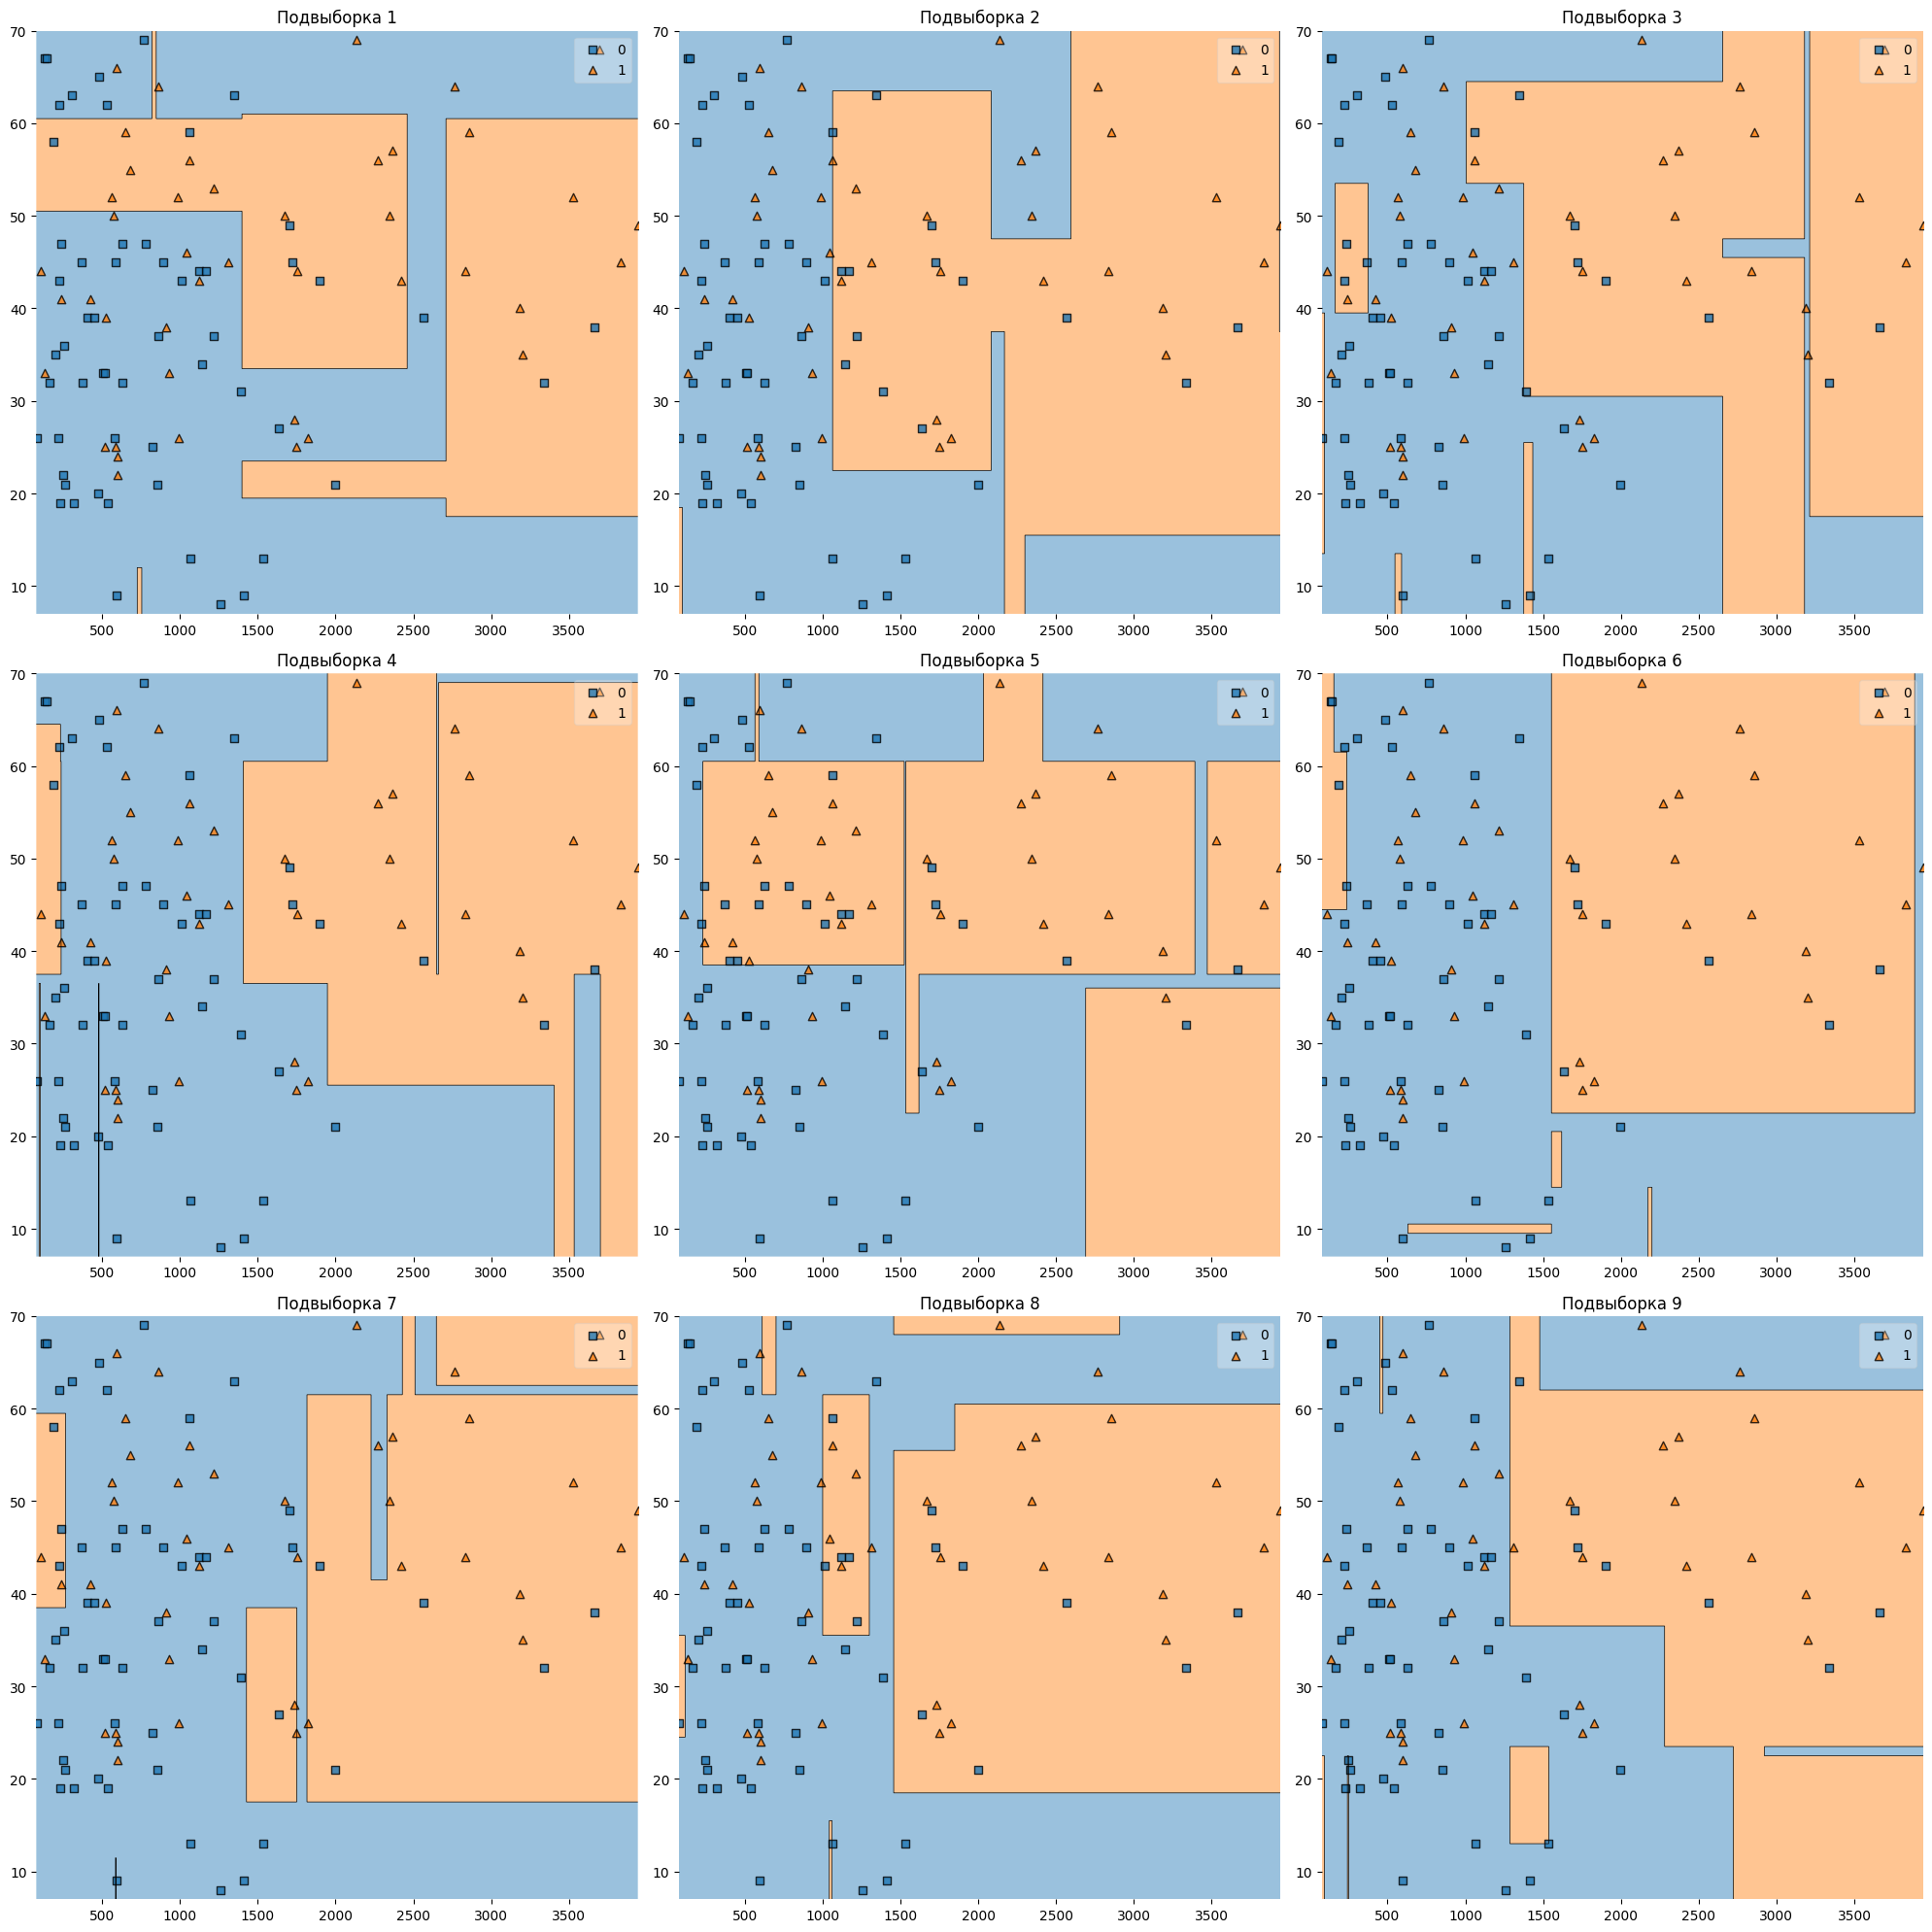

In [75]:
X_test_fixed = X_train_top2.iloc[:100].astype(np.float64).values
y_test_fixed = y_train_bin.iloc[:100].astype(np.int64).values

fig, ax = plt.subplots(3, 3, figsize=(20, 20))

for row in range(3):
    for col in range(3):
        available_indices = X_train_top2.index.intersection(y_train_bin.index)
        inds = np.random.choice(available_indices,
                               size=min(1000, len(available_indices)),
                               replace=False)

        X_train_subset = X_train_top2.loc[inds].astype(np.float64)
        y_train_subset = y_train_bin.loc[inds].astype(np.int64)

        tree_exp = DecisionTreeClassifier(max_depth=5, random_state=42)
        tree_exp.fit(X_train_subset, y_train_subset)

        plot_decision_regions(clf=tree_exp, X=X_test_fixed, y=y_test_fixed,
                             ax=ax[row, col])
        ax[row, col].set_title(f'Подвыборка {row*3+col+1}')

plt.tight_layout()
plt.show()

**Смотрите как двигается гранится, а ведь мы убирали из трейна (а в нем ~80к наблюдений) всего по тысяче случайных объектов!**

Помимо своей неусточивости деревья решений "славны" ещё и склонностью к переобучению. Посмотрим, можно ли увидеть это свойство на имеющихся у нас данных. Для этого будем обучать алгоритм DT на всем трейне с разной глубиной дерева и считать accuracy для теста

In [41]:
# замените X_train_example на вашу переменную (ohe-encoded)

%%time
depths = [2, 3, 5, 10, 15, 20, 25, 32, 50, 64, 75, 100]

accuracies_train = []
accuracies_test = []
for max_depth in depths:
    DT = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    DT.fit(X_train_ohe, y_train_bin)
    y_predicted_train = DT.predict(X_train_ohe)
    y_predicted_val = DT.predict(X_val_ohe)
    accuracies_train.append(accuracy_score(y_train_bin, y_predicted_train))
    accuracies_test.append(accuracy_score(y_val_bin, y_predicted_val))

CPU times: user 11.3 s, sys: 6.59 ms, total: 11.3 s
Wall time: 12.3 s


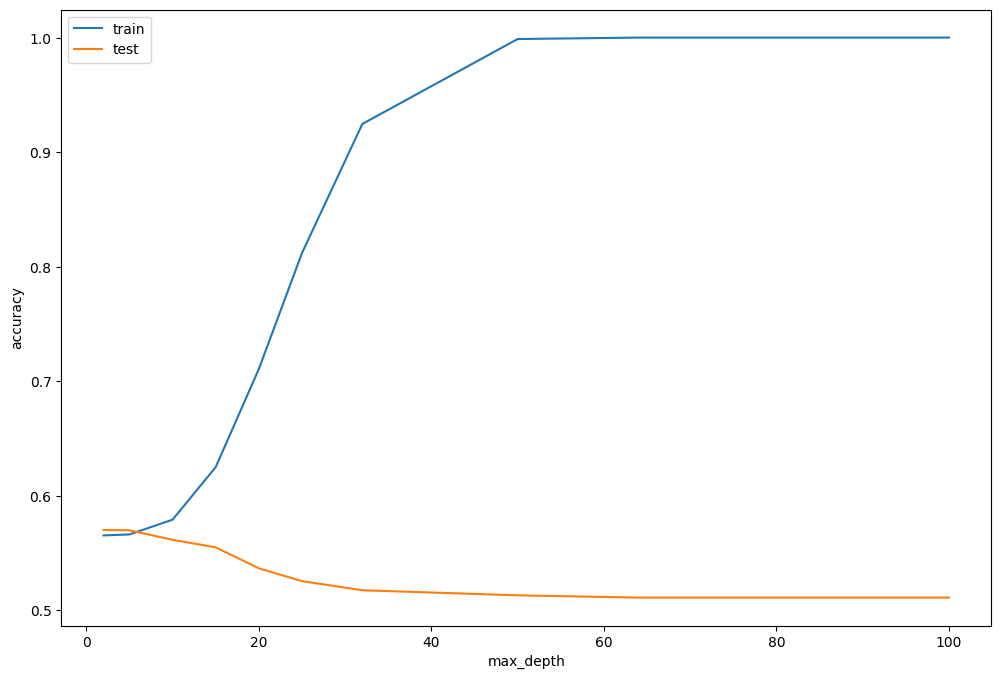

In [78]:
plt.figure(figsize=(12, 8))
plt.plot(depths, accuracies_train, depths, accuracies_test)
plt.legend(['train', 'test'])
plt.ylabel('accuracy')
plt.xlabel('max_depth')
plt.show()

Нам повезло выйти на ассимптоту на тесте. Однако так бывает далеко не всегда. Так что подбирать гипрепараметры для деревьев решений стоит осторожно

## **Возвращение к задаче**

### **Задание 20. (0.4 балла)**

- На кроссвалидации подберите оптимальные гиперпараметры для дерева решений *(по данным со всеми признаками -- не на модельном примере из теоретической вставки)*.
- Удалось ли улучшить качество предсказаний подбором гиперпараметров?

In [42]:
param_grid = {
    'max_depth': [5, 10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': ['sqrt', 'log2', None]
}

dt_base = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    dt_base,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)


grid_search.fit(X_train_ohe, y_train_bin)


print("лучшие параметры:")
print(grid_search.best_params_)
print(f"Лучший CV-score: {grid_search.best_score_}")



Fitting 5 folds for each of 288 candidates, totalling 1440 fits
лучшие параметры:
{'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5}
Лучший CV-score: 0.5643252447850149


In [43]:
from sklearn.model_selection import cross_val_score
dt_default = DecisionTreeClassifier(random_state=42)
cv_default = cross_val_score(dt_default, X_train_ohe, y_train_bin, cv=5, scoring='accuracy')
print(f"базовая модель: CV-score = {cv_default.mean()} ± {cv_default.std()}")

print(f"улучшениеЕ: +{(grid_search.best_score_ - cv_default.mean())}")

best_dt = grid_search.best_estimator_
val_accuracy_default = accuracy_score(y_val_bin, dt_default.fit(X_train_ohe, y_train_bin).predict(X_val_ohe))
val_accuracy_best = accuracy_score(y_val_bin, best_dt.predict(X_val_ohe))

print(f"ВАЛИДАЦИОННАЯ выборка:")
print(f"Базовая модель:  {val_accuracy_default}")
print(f"Оптимизированная: {val_accuracy_best}")
print(f"Улучшение: +{(val_accuracy_best - val_accuracy_default)}")

базовая модель: CV-score = 0.5053214133673903 ± 0.0037536317633003616
улучшениеЕ: +0.05900383141762455
ВАЛИДАЦИОННАЯ выборка:
Базовая модель:  0.5040209153787603
Оптимизированная: 0.5704404805242083
Улучшение: +0.066419565145448


### **Задание 21. (0.1 балла)**

- Сохраните лучшее дерево в pickle

*Мы просим это сделать, чтобы вы в случае чего не тратили время на переобучение, а могли банально подгрузить из файла*

In [44]:
best_dt = grid_search.best_estimator_
with open('DT.pkl', 'wb') as f:
    pickle.dump(best_dt, f)
with open('DT.pkl', 'rb') as f:
    loaded_dt = pickle.load(f)
val_accuracy_loaded = accuracy_score(y_val_bin, loaded_dt.predict(X_val_ohe))
print(f"Accuracy загруженной модели на val: {val_accuracy_loaded:.4f}")

Accuracy загруженной модели на val: 0.5704


# **Часть 3. Random Forest (4.25 балла)**

### **Задание 22. (0.05 балла)**
- Обучите случайный лес с параметрами по умолчанию

In [62]:
rf_default = RandomForestClassifier(
    random_state=42
)

rf_default.fit(X_train_ohe, y_train_bin)

y_train_pred_rf = rf_default.predict(X_train_ohe)
y_val_pred_rf = rf_default.predict(X_val_ohe)

train_accuracy_rf = accuracy_score(y_train_bin, y_train_pred_rf)
val_accuracy_rf = accuracy_score(y_val_bin, y_val_pred_rf)

print("Случайный лес (параметры по умолчанию):")
print(f"Train accuracy: {train_accuracy_rf}")
print(f"Val accuracy:  {val_accuracy_rf}")
print(f"Количество деревьев: {rf_default.n_estimators}")
print(f"Глубина деревьев: {rf_default.estimators_[0].tree_.max_depth}")



Случайный лес (параметры по умолчанию):
Train accuracy: 1.0
Val accuracy:  0.5395638216897772
Количество деревьев: 100
Глубина деревьев: 52


### **Задание 23. (0.15 балла)**
- Выведите калибровочную кривую для полученного ансамбля

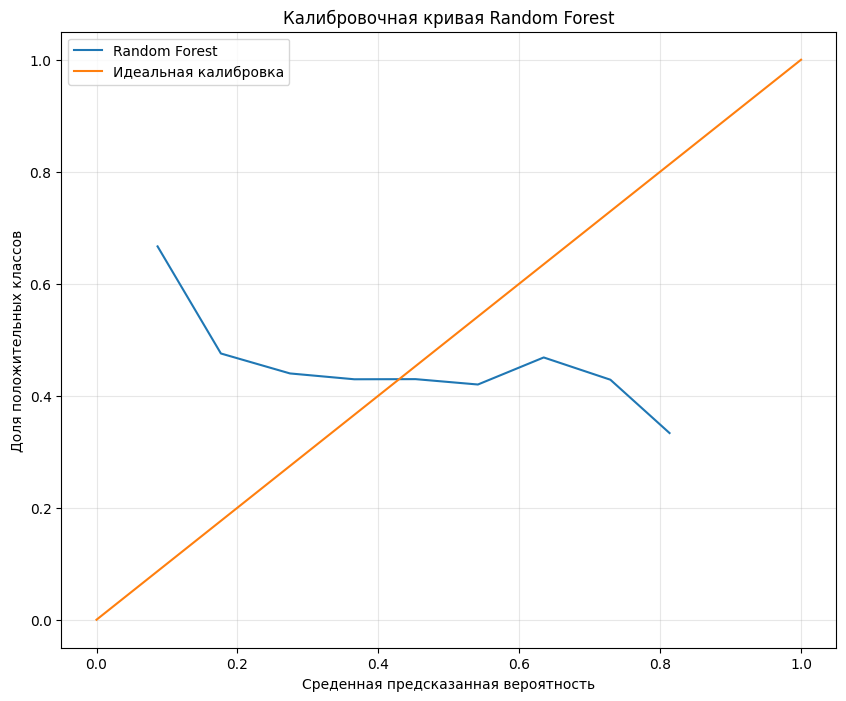

In [46]:
from sklearn.calibration import calibration_curve
y_pred_proba_rf = rf_default.predict_proba(X_val_ohe)[:, 1]

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_val_bin, y_pred_proba_rf, n_bins=10
)

plt.figure(figsize=(10, 8))
plt.plot(mean_predicted_value, fraction_of_positives, label="Random Forest")
plt.plot([0, 1], [0, 1], label="Идеальная калибровка")
plt.xlabel("Среденная предсказанная вероятность")
plt.ylabel("Доля положительных классов")
plt.title("Калибровочная кривая Random Forest")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Похоже, мы немного недооцениваем высокие вероятности

<img src='https://habrastorage.org/r/w1560/getpro/habr/upload_files/510/4e0/63b/5104e063b62bd0ac6b87da44a3034aa5.png'>

Изображение взято из статьи ["predict_proba в Python не прогнозирует вероятности (и как с этим бороться)"](https://habr.com/ru/company/otus/blog/573924/) с Хабра

### **Задание 24. (0.4 балла)**

- Вспомните (или выведите), корректно ли деревья предсказывают вероятности?



Деревья предсказывают вероятности некорректно. Деревья решений дают оценки вероятностей, но эти оценки часто не являются хорошо калиброванными (слишком уверенными или несогласованными). По сути при обучении дерева в каждом листе считается доля объектов каждого класса в обучающей выборке, попавшей в этот лист.
Случайный лес делает это получше за счет усреднения вероятностей по многим деревьям, что сглаживает резкие скачки и улучшает оценку, но все еще не очень.


### **Задание 25. (0.15 балла)**
- Обучите логистическую регрессию так, чтобы она сошлась
- Отобразите её калибровочную кривую

Модель сошлась за 15 итераций


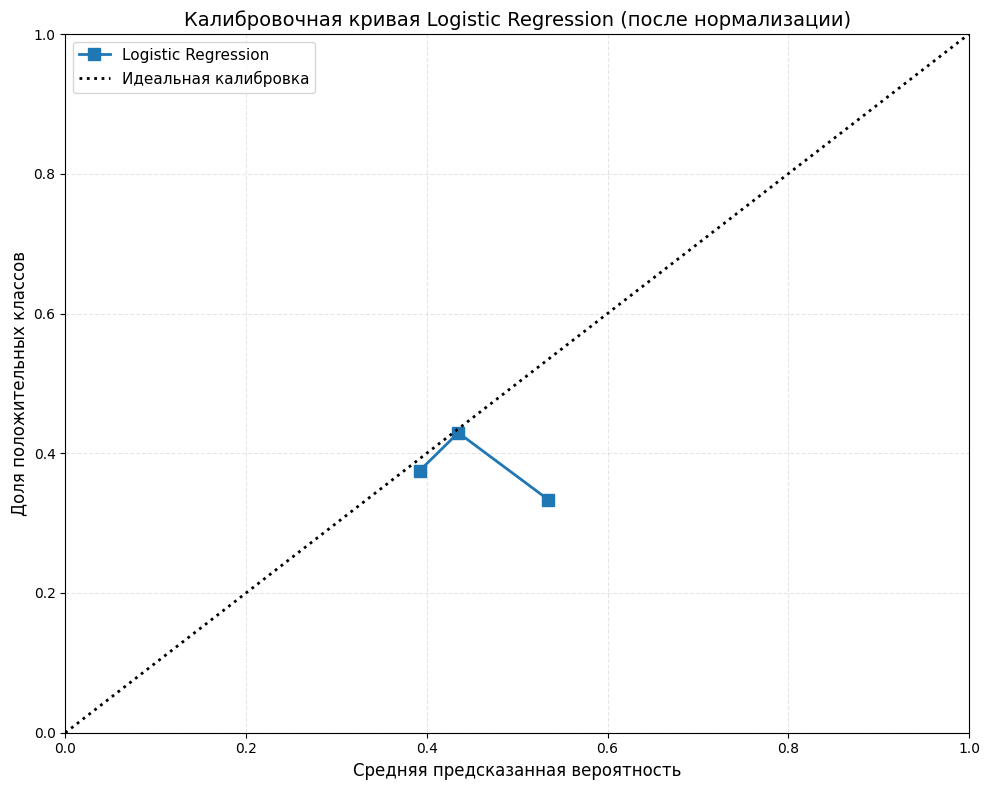

Val accuracy: 0.5705


In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ohe)
X_val_scaled = scaler.transform(X_val_ohe)


logreg = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    tol=1e-4,
    random_state=42,
    verbose=1
)

try:
    logreg.fit(X_train_scaled, y_train_bin)
    print(f"Модель сошлась за {logreg.n_iter_[0]} итераций")
except Exception as e:
    print(f"Ошибка обучения: {e}")
    logreg.fit(X_train_scaled, y_train_bin)

y_pred_proba_logreg = logreg.predict_proba(X_val_scaled)[:, 1]

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_val_bin, y_pred_proba_logreg, n_bins=10, strategy='uniform'
)

plt.figure(figsize=(10, 8))
plt.plot(mean_predicted_value, fraction_of_positives, "s-",
         linewidth=2, markersize=8, label="Logistic Regression")
plt.plot([0, 1], [0, 1], "k:", linewidth=2, label="Идеальная калибровка")
plt.xlabel("Средняя предсказанная вероятность", fontsize=12)
plt.ylabel("Доля положительных классов", fontsize=12)
plt.title("Калибровочная кривая Logistic Regression (после нормализации)", fontsize=14)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc="best", fontsize=11)
plt.tight_layout()
plt.show()
print(f"Val accuracy: {accuracy_score(y_val_bin, logreg.predict(X_val_scaled)):.4f}")


Мы немного переоцениваем предсказанные низкие вероятности

### **Задание 26. (0.2 балла)**
- Покажите, почему считается, что логистическая регрессия корректно предсказывает вероятности?


 В отличие от деревьев (доля в листе), LR прямо моделирует условную вероятность!
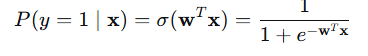



### **Задание 27. (0.35 балла)**

Предлагаем вам попробовать откалибровать вероятности обученного случайного леса!

- Откалибруйте вероятности, при помощи логистической и изотонической регрессий.
- Интерпретируйте полученные результаты

In [56]:
y_proba_rf = rf_default.predict_proba(X_val_ohe)[:, 1]
# ЛОГРЕГ
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
X_calib, _, y_calib, _ = train_test_split(y_proba_rf.reshape(-1, 1), y_val_bin, test_size=0.3, random_state=42)
calib_logreg = LogisticRegression()
calib_logreg.fit(X_calib, y_calib)
y_proba_logistic = calib_logreg.predict_proba(y_proba_rf.reshape(-1, 1))[:, 1]
# ИЗОРЕГ
from sklearn.isotonic import IsotonicRegression
calib_isotonic = IsotonicRegression(out_of_bounds='clip')
calib_isotonic.fit(X_calib.ravel(), y_calib)
y_proba_isotonic = calib_isotonic.predict(y_proba_rf)

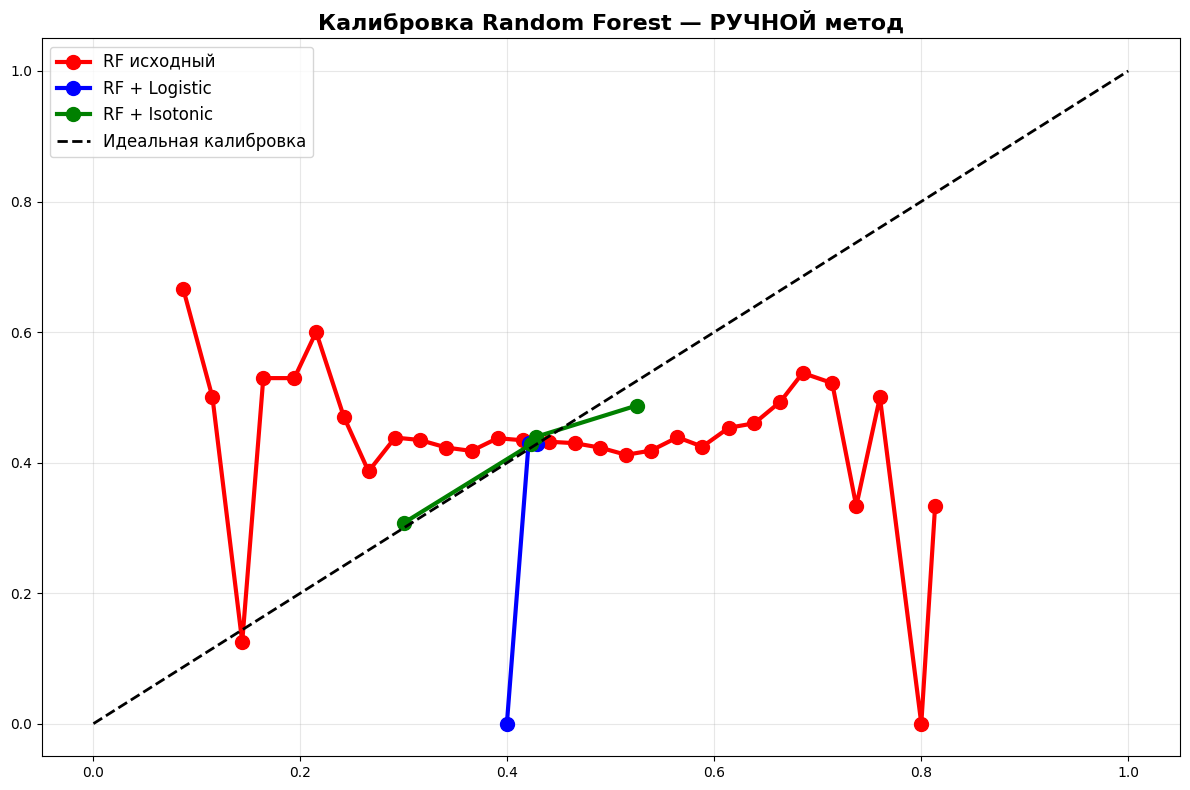

In [58]:
fig, ax = plt.subplots(figsize=(12, 8))

models = [
    (y_proba_rf, "RF исходный", "red"),
    (y_proba_logistic, "RF + Logistic", "blue"),
    (y_proba_isotonic, "RF + Isotonic", "green")
]

for y_proba, label, color in models:
    fraction_pos, mean_pred = calibration_curve(y_val_bin, y_proba, n_bins=40)
    ax.plot(mean_pred, fraction_pos, "o-", label=label, color=color, linewidth=3, markersize=10)

ax.plot([0, 1], [0, 1], "k--", label="Идеальная калибровка", linewidth=2)
ax.set_title("Калибровка Random Forest — РУЧНОЙ метод", fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Задание 28. (0.2 балла)**
- Опишите другие возвожные подходы к калибровке вероятностей (со ссылками на источники)

Ответ:

1. Probability Calibration Trees (PCT). источник - https://arxiv.org/abs/1612.06853

2. Beta Calibration. источник - https://arxiv.org/abs/1809.12525

3. Temperature Scaling (для нейросетей). источник - https://arxiv.org/abs/1706.04599


### **Задание 29. (0.5 баллa)**

Проанализируйте лес.
- Посчитайте разброс и смещение полученного случайного леса (до калибровки).
- Оличаются ли они от полученных для дерева решений?
- Соответствуют ли полученные на реальных данных отличия (//совпадения) от тех, что должны быть в теории? По каким причинам?

In [67]:
def bias_variance_cv(model, X, y, cv=5):
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    bias = 1 - cv_scores.mean()
    variance = cv_scores.std()
    return bias, variance
# Дерево с параметрами по умолчанию
print("Decision Tree по умолчанию")
print(f" Bias: {bias_dt}")
print(f" Variance: {var_dt}")

# Дерево оптимизированное
print("Decision Tree оптимизированный ")
dt_bias, dt_variance = bias_variance_cv(grid_search.best_estimator_, X_train_ohe, y_train_bin)
print(f" Bias: {dt_bias}")
print(f" Variance:  {dt_variance}")

# Random Forest по умолчанию
print("Random Forest до калибровки")
rf_bias, rf_variance = bias_variance_cv(rf_default, X_train_ohe, y_train_bin)
print(f" Bias: {rf_bias}")
print(f" Variance:{rf_variance}")


Decision Tree по умолчанию
 Bias: 0.46159446669093557
 Variance: 0.4244430287586458
Decision Tree оптимизированный 
 Bias: 0.4356747552149851
 Variance:  0.0006259896409851676
Random Forest до калибровки
 Bias: 0.46262239250744996
 Variance:0.004073767369205848


Ответ:

1. По смещению (Bias):
Теория: RF обычно имеет немного большее смещение, чем одно дерево, из-за усреднения

Реальность: Bias у RF (0.463) почти равен DT (0.462) - соответствует теории

2. По разбросу (Variance):
Теория: RF должен значительно снижать разброс по сравнению с одним деревом

Реальность:

DT default: Variance = 0.424 (очень высокий)

RF: Variance = 0.004 (снизил в 100 раз) - полностью соответствует теории


### **Задание 30. (0.5 баллa)**

- Вычислите разложение ошибки для логистической регрессии (ванильной, которую вы обучили для решения задачи в задании 25, а не той, что использовали для калибровки)
- Сравните полученные результаты с предыдущими.
- Объясните природу этих результатов

In [65]:
lr_bias, lr_variance = bias_variance_cv(logreg, X_train_ohe, y_train_bin, cv=5)
print(f"  Bias: {lr_bias}")
print(f"  Variance: {lr_variance}")
print(f"  Val acc: {accuracy_score(y_val_bin, logreg.predict(X_val_ohe))}")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refe

  Bias: 0.4348942812544345
  Variance: 0.00018283097384311686
  Val acc: 0.5708707019227587


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Сравнение моделей:

LR имеет самое низкое смещение среди всех моделей.

LR показывает наименьший разброс (самая стабильная модель)

LR и DT показывают реалистичную точность, RF явно переобучен.

Объяснение полученных результатов:

1. Есть 25 OHE-признаков, которые  линейно разделимыы, следовательно идеально подходят для LR
2. Линейные модели обычно имеют низкий variance. Деревья же наоборот имеют высокий variance и следовательно могут сильно меняться при небольших изменениях данных.
RF снизил variance по сравнению с одним деревом, но из-за неподобранных параметров не может соревноваться с LRЮ



### **Задание 31. (0.8 баллa)**

- Попробуйте подобрать оптимальные гиперпараметры леса, используя [RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html).

**Важно:**  

Хотя бы один из гиперпараметров перебирайте из распределения (например, `uniform` из `scipy.stats`)

In [70]:
from scipy.stats import randint, uniform
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [8, 12, 15, 20, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'bootstrap': [True, False]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train_ohe, y_train_bin)
print(f"Лучшие параметры: {rf_search.best_params_}")
print(f" Лучшая accuracy: {rf_search.best_score_}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Лучшие параметры: {'bootstrap': True, 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 17, 'n_estimators': 448}
 Лучшая accuracy: 0.5649354335178091


## **Случайный лес. Вставка теории**

На модельном примере посмотрим, склонен ли случайный лес к переобучению с ростом числа деревьев в композиции.

Возьмем 4 полезных признака из одного из предыдщущих заданий, напоминающих теорию

In [ ]:
# замените X_train_enc на ваш трейн

cols_for_RF = ['age', 'Flight Distance', 'Online boarding', 'Inflight wifi service']
X_train_RF = X_train_enc[cols_for_RF]
# а тест нам не понадобится, ведь можно получить OOB-estimate ошибки

clf = RandomForestClassifier(warm_start=True, oob_score=True, random_state=42)
errors = []

for n_estimators in range(1, 251, 5):
    clf.set_params(n_estimators=n_estimators)
    clf.fit(X_train_RF, y_train)

    errors.append(1 - clf.oob_score_)

In [ ]:
plt.figure(figsize=(20, 14))
plt.plot(range(1, 251, 5), errors)

plt.xlabel('n_estimators')
plt.ylabel('OOB score')
plt.show()

**Дисклеймер**: отсутствие переобучения с ростом числа деревьев вовсе не означает, что сама модель случайного леса не может быть переобучена. Базовые деревья такой композиции могут переобучаться. Значит, и вся композиция вполне способна оказаться переобученной

## **Возвращение к задаче**

### **Задание 32. (0.6 баллa)**

- Отобразите`feature_importances_` вашего лучшего случайного леса
- Сравните важности признаков для дерева решений и для случайного леса. Постройте диаграмму


In [72]:
dt_importances = dt_default.feature_importances_
rf_importances = rf_search.best_estimator_.feature_importances_

feature_df = pd.DataFrame({
    'feature': X_train_ohe.columns,
    'DT_importance': dt_importances,
    'RF_importance': rf_importances
}).sort_values('RF_importance', ascending=False)

print(feature_df.head(25).round(3))

                              feature  DT_importance  RF_importance
1                     Flight Distance          0.199          0.137
0                                 age          0.122          0.100
19                  log_Arrival_Delay          0.037          0.073
3            Arrival Delay in Minutes          0.038          0.072
2          Departure Delay in Minutes          0.038          0.070
18                log_Departure_Delay          0.039          0.069
13                   Leg room service          0.039          0.034
15                    Checkin service          0.029          0.033
5   Departure/Arrival time convenient          0.039          0.033
7                       Gate location          0.042          0.032
9                     Online boarding          0.033          0.031
4               Inflight wifi service          0.034          0.031
6              Ease of Online booking          0.038          0.031
12                   On-board service          0

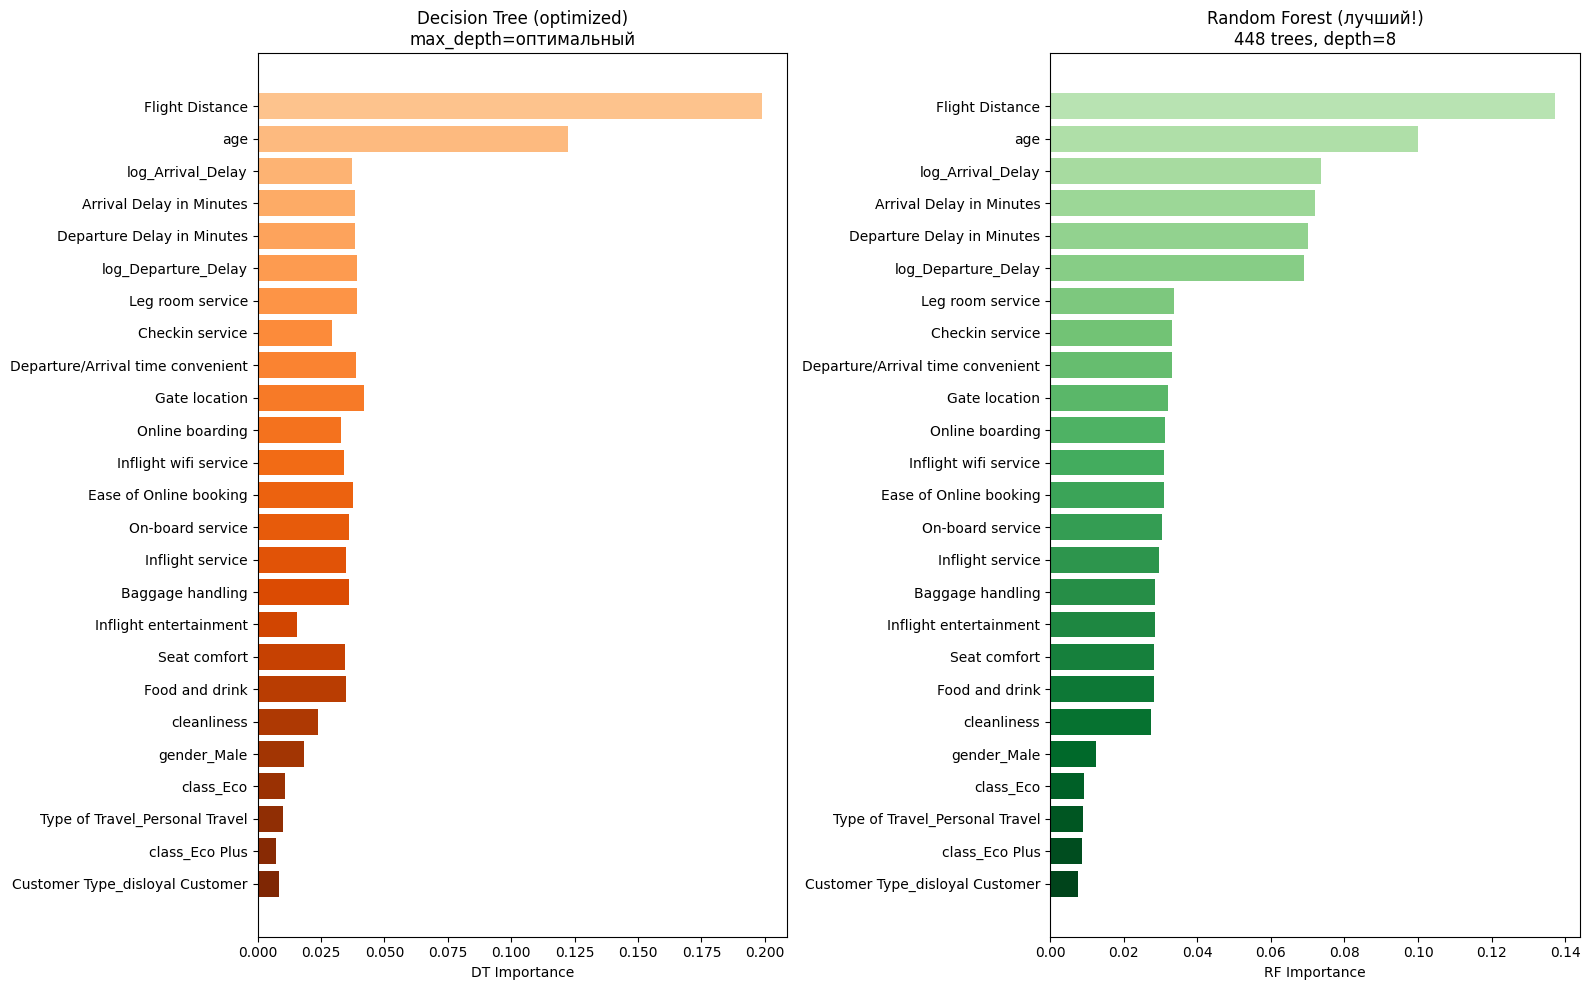

In [74]:
top = feature_df.head(25)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))
colors1 = plt.cm.Oranges(np.linspace(0.3, 1, len(top)))
colors2 = plt.cm.Greens(np.linspace(0.3, 1, len(top)))


ax1.barh(range(len(top)), top['DT_importance'], color=colors1)
ax1.set_yticks(range(len(top)))
ax1.set_yticklabels(top['feature'])
ax1.set_xlabel('DT Importance')
ax1.set_title('Decision Tree (optimized)\nmax_depth=оптимальный')
ax1.invert_yaxis()

ax2.barh(range(len(top)), top['RF_importance'], color=colors2)
ax2.set_yticks(range(len(top)))
ax2.set_yticklabels(top['feature'])
ax2.set_xlabel('RF Importance')
ax2.set_title('Random Forest (лучший!)\n448 trees, depth=8')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

### **Задание 33. (0.1 баллa)**

- Случайный лес, дающий лучший скор, [сохраните в pickle](https://scikit-learn.ru/stable/model_persistence.html)

In [76]:
with open('rf_search_model.pkl', 'wb') as f:
    pickle.dump(rf_search, f)
print("Модель сохранена: rf_search_model.pkl")


Модель сохранена: rf_search_model.pkl


### **Задание 34. (0.25 балла)**
- Интерпретируйте важности признаков с помощью SHAP.
- Опишите полученый график

**Важно:** Для подсчета используйте 1000 случайных объектов, иначе не дождетесь за приемлемое время

**Вам может помочь:** [Статья "Интерпретация моделей и диагностика сдвига данных: LIME, SHAP и Shapley Flow"](https://habr.com/ru/company/ods/blog/599573/) из блога ods.ai на Хабре

In [ ]:
# Ваш код здесь


`Ваш ответ здесь`

### **Бонус (0.1 балл)**

- Изучите документацию библиотеки SHAP. Что ещё полезного в ней имеется?

`Ваш ответ здесь`

### **Бонус (0.5 балла)**

- Интерпретируйте важности признаков для одного прогноза с помощью LIME;
- Опишите полученный график для выбранного наблюдения

In [ ]:
# Ваш код здесь


`Ваш ответ здесь`

# Обратная связь

Расскажите, как вам это домашнее задание. Было ли оно полезным? Научились ли вы чему то? Насколько сложным по 10-балльной шкале оно вам показалось? Сколько времени у вас ушло на его выполнение? Что следовало ещё в него включить? Было ли что-то лишнее?